In [7]:
# =============================================================================
# BLOQUE 1 — CARGA, FILTRADO Y EXPLORACIÓN INICIAL DEL DATASET
# =============================================================================
# TFG: Predicción del éxito de campañas en Kickstarter mediante Machine Learning
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# Descargar el dataset si no existe
# -----------------------------------------------------------------------------
import os
if not os.path.exists('ks-projects-201801.csv'):
    print("Descargando 'ks-projects-201801.csv'...")
    !wget -q https://github.com/josemanuelcruz/kickstarter-ml/raw/main/ks-projects-201801.csv
    print("Descarga completada.")

# -----------------------------------------------------------------------------
# 1.1 Carga del dataset
# -----------------------------------------------------------------------------

df = pd.read_csv('ks-projects-201801.csv', encoding='latin-1')

print("=" * 60)
print("DATASET ORIGINAL")
print("=" * 60)
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nDistribución de 'state':")
print(df['state'].value_counts())

# -----------------------------------------------------------------------------
# 1.2 Filtrado: conservar solo successful y failed
# -----------------------------------------------------------------------------

df = df[df['state'].isin(['successful', 'failed'])].copy()

print("\n" + "=" * 60)
print("DATASET FILTRADO")
print("=" * 60)
print(f"Proyectos válidos: {len(df):,}")
print(f"\nDistribución de clases:")
conteo = df['state'].value_counts()
for estado, n in conteo.items():
    print(f"  {estado:12s}: {n:,} ({n/len(df)*100:.1f}%)")

# -----------------------------------------------------------------------------
# 1.3 Creación de la variable objetivo binaria
# -----------------------------------------------------------------------------

df['target'] = (df['state'] == 'successful').astype(int)

print("\n" + "=" * 60)
print("VARIABLE OBJETIVO (target)")
print("=" * 60)
print(f"  0 — Fracaso: {(df['target'] == 0).sum():,}")
print(f"  1 — Éxito:   {(df['target'] == 1).sum():,}")

# -----------------------------------------------------------------------------
# 1.4 Exploración inicial
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PRIMERAS 5 FILAS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("TIPOS DE VARIABLES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("VALORES NULOS POR COLUMNA")
print("=" * 60)
print(df.isnull().sum())

DATASET ORIGINAL
Filas:    378,661
Columnas: 15

Distribución de 'state':
state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846
Name: count, dtype: int64

DATASET FILTRADO
Proyectos válidos: 331,675

Distribución de clases:
  failed      : 197,719 (59.6%)
  successful  : 133,956 (40.4%)

VARIABLE OBJETIVO (target)
  0 — Fracaso: 197,719
  1 — Éxito:   133,956

PRIMERAS 5 FILAS
           ID                                               name  \
0  1000002330                    The Songs of Adelaide & Abullah   
1  1000003930      Greeting From Earth: ZGAC Arts Capsule For ET   
2  1000004038                                     Where is Hank?   
3  1000007540  ToshiCapital Rekordz Needs Help to Complete Album   
5  1000014025                               Monarch Espresso Bar   

         category main_category currency    deadline     goal  \
0          Poetry    Publishing      GBP  2015-10-09   1000.0   
1  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Bloque 1 — Lo primero que he hecho ha sido cargar el dataset de Kaggle con los 378.661 proyectos de Kickstarter. Nada más cargarlo lo he filtrado para quedarme solo con los proyectos que tienen un resultado claro, es decir, los exitosos y los fracasados, eliminando los cancelados, en curso o suspendidos. Al final me quedo con 331.675 proyectos válidos, de los cuales el 40,4% son éxitos y el 59,6% fracasos. Esto ya nos dice algo importante: en Kickstarter fracasar es lo más habitual, lo que justifica la necesidad de herramientas predictivas que ayuden a los creadores a evaluar sus probabilidades antes de lanzar una campaña. También he comprobado que el dataset está en buen estado, con muy pocos valores nulos y en ninguna de las variables que voy a usar.

In [8]:
# =============================================================================
# BLOQUE 2 — VARIABLES DERIVADAS Y ESTADÍSTICAS DESCRIPTIVAS
# =============================================================================

# -----------------------------------------------------------------------------
# 2.1 Conversión de fechas y cálculo de duración de la campaña
# -----------------------------------------------------------------------------

df['launched'] = pd.to_datetime(df['launched'])
df['deadline'] = pd.to_datetime(df['deadline'])
df['duracion_dias'] = (df['deadline'] - df['launched']).dt.days

# -----------------------------------------------------------------------------
# 2.2 Extracción de año y mes de lanzamiento
# -----------------------------------------------------------------------------

df['año_lanzamiento'] = df['launched'].dt.year
df['mes_lanzamiento'] = df['launched'].dt.month

# -----------------------------------------------------------------------------
# 2.3 Transformación logarítmica del objetivo de financiación
# -----------------------------------------------------------------------------

df['log_goal'] = np.log1p(df['usd_goal_real'])

print("=" * 60)
print("DURACIÓN DE LA CAMPAÑA (días)")
print("=" * 60)
print(df['duracion_dias'].describe().round(2))
print(f"\nDuración media — Éxito:   {df[df['target']==1]['duracion_dias'].mean():.1f} días")
print(f"Duración media — Fracaso: {df[df['target']==0]['duracion_dias'].mean():.1f} días")

print("\n" + "=" * 60)
print("AÑO Y MES DE LANZAMIENTO")
print("=" * 60)
print(f"Años disponibles: {sorted(df['año_lanzamiento'].unique())}")
print(f"\nProyectos por año:")
print(df['año_lanzamiento'].value_counts().sort_index())
print(f"\nTasa de éxito por año:")
print((df.groupby('año_lanzamiento')['target'].mean() * 100).round(1))

print("\n" + "=" * 60)
print("OBJETIVO DE FINANCIACIÓN (usd_goal_real)")
print("=" * 60)
print(f"\nSin transformación:")
print(df['usd_goal_real'].describe().round(2))
print(f"\nCon transformación logarítmica (log_goal):")
print(df['log_goal'].describe().round(2))
print(f"\nMedia — Éxito:     ${df[df['target']==1]['usd_goal_real'].mean():,.0f}")
print(f"Media — Fracaso:   ${df[df['target']==0]['usd_goal_real'].mean():,.0f}")
print(f"Mediana — Éxito:   ${df[df['target']==1]['usd_goal_real'].median():,.0f}")
print(f"Mediana — Fracaso: ${df[df['target']==0]['usd_goal_real'].median():,.0f}")

DURACIÓN DE LA CAMPAÑA (días)
count    331675.00
mean         32.95
std          12.71
min           0.00
25%          29.00
50%          29.00
75%          35.00
max          91.00
Name: duracion_dias, dtype: float64

Duración media — Éxito:   31.2 días
Duración media — Fracaso: 34.2 días

AÑO Y MES DE LANZAMIENTO
Años disponibles: [np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]

Proyectos por año:
año_lanzamiento
2009     1179
2010     9577
2011    24049
2012    38480
2013    41101
2014    59306
2015    65272
2016    49292
2017    43419
Name: count, dtype: int64

Tasa de éxito por año:
año_lanzamiento
2009    49.1
2010    48.0
2011    50.6
2012    46.5
2013    47.2
2014    35.6
2015    32.1
2016    38.1
2017    42.5
Name: target, dtype: float64

OBJETIVO DE FINANCIACIÓN (usd_goal_real)

Sin transformación:
count    3.316750e+05
mean     4.151000e+04
std      1.108930e+06
min      1.000000

Bloque 2 — En este bloque he creado las variables nuevas que necesito para el análisis. He calculado la duración de cada campaña en días restando la fecha de lanzamiento a la fecha límite, y he extraído el año y el mes de lanzamiento. También he aplicado una transformación logarítmica al objetivo de financiación porque tiene valores muy extremos que van desde menos de un dólar hasta 166 millones, lo que podría distorsionar los modelos. Los resultados ya muestran patrones claros: las campañas exitosas duran de media 31,2 días frente a los 34,2 días de las fracasadas, y tienen objetivos mucho más modestos, con una mediana de 3.838 dólares frente a los 7.500 dólares de las fracasadas. Respecto al año de lanzamiento, la tasa de éxito varía bastante a lo largo del tiempo, desde el 50% en los primeros años hasta el 32% en 2015, lo que confirma que incluir esta variable puede aportar información útil al modelo dentro del rango temporal del dataset.

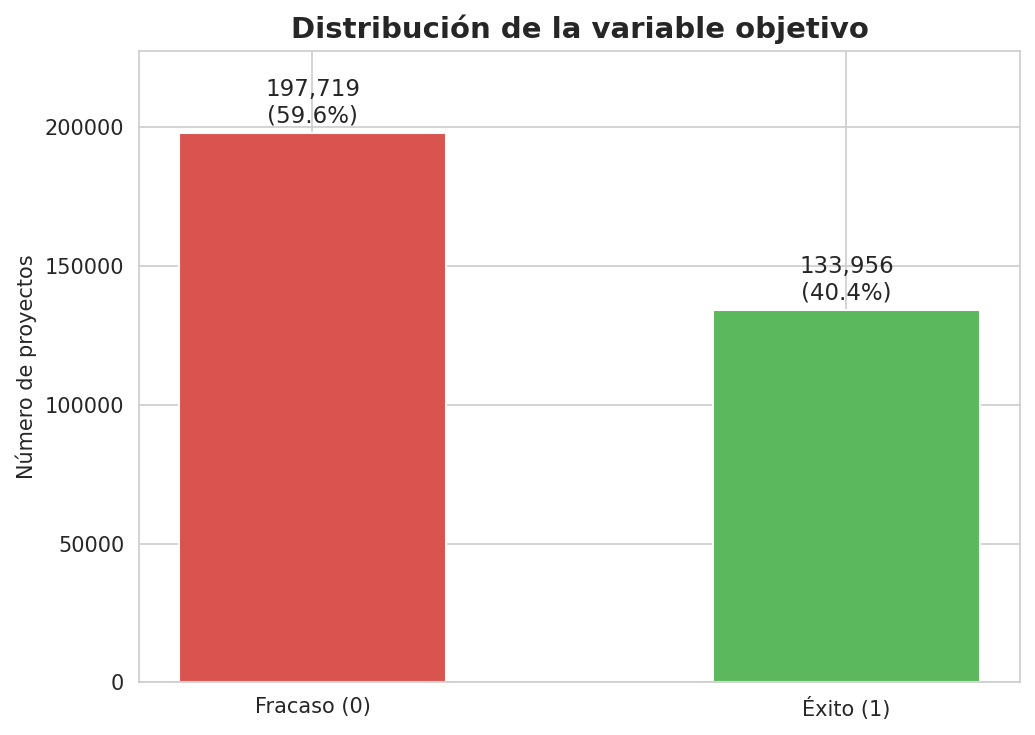

 Gráfico 1 guardado


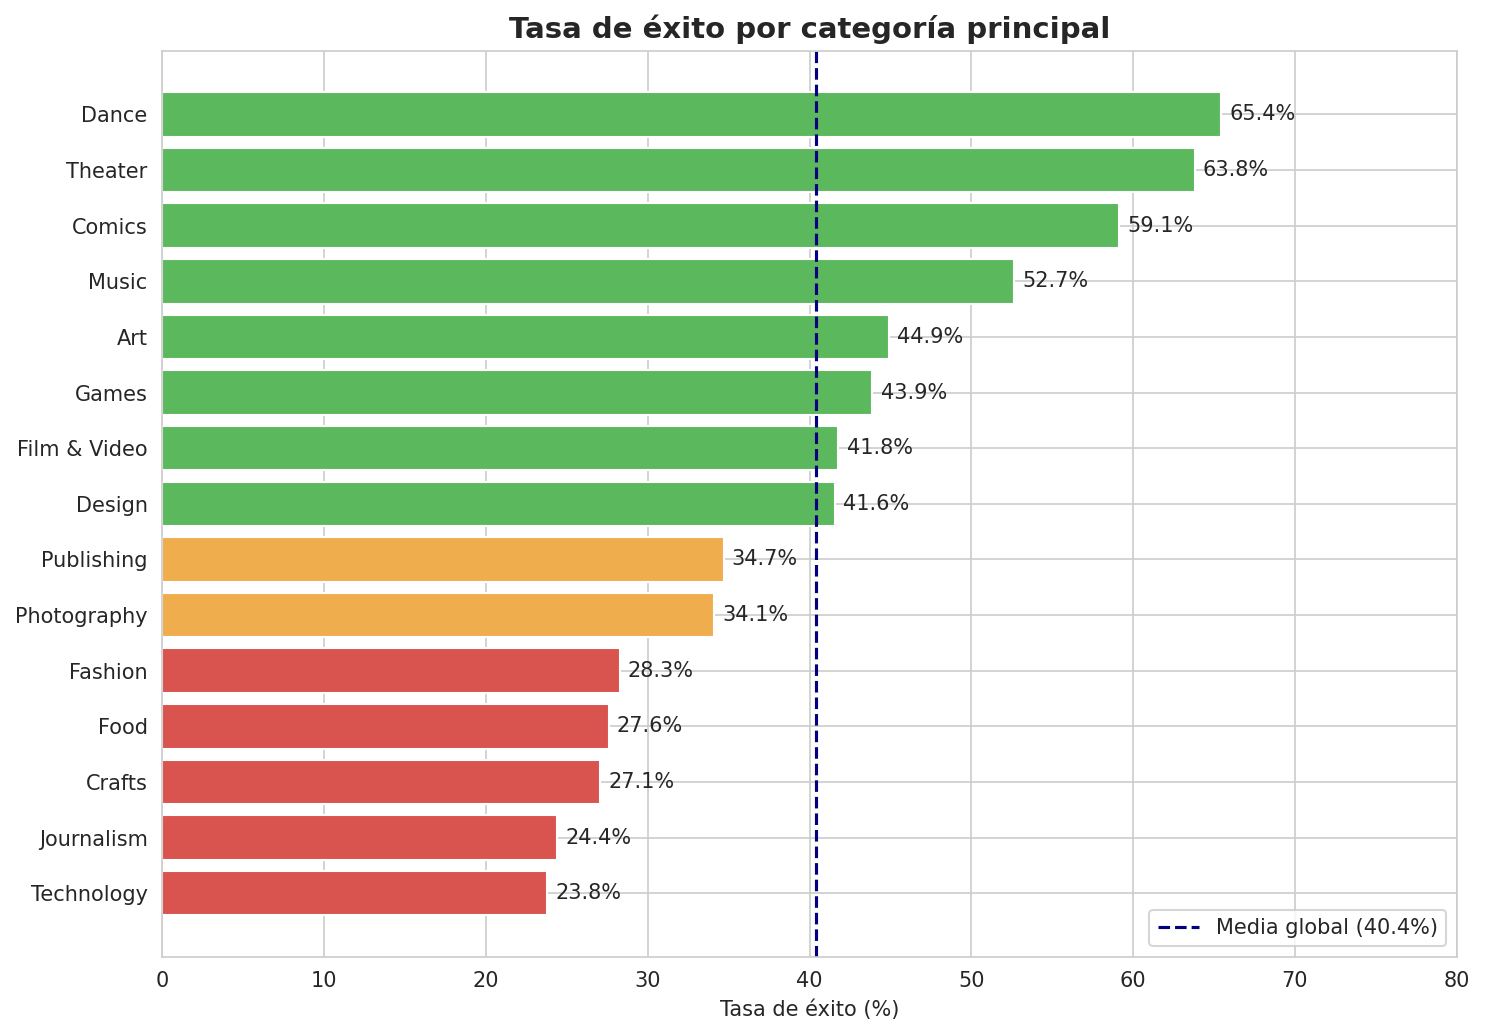

 Gráfico 2 guardado


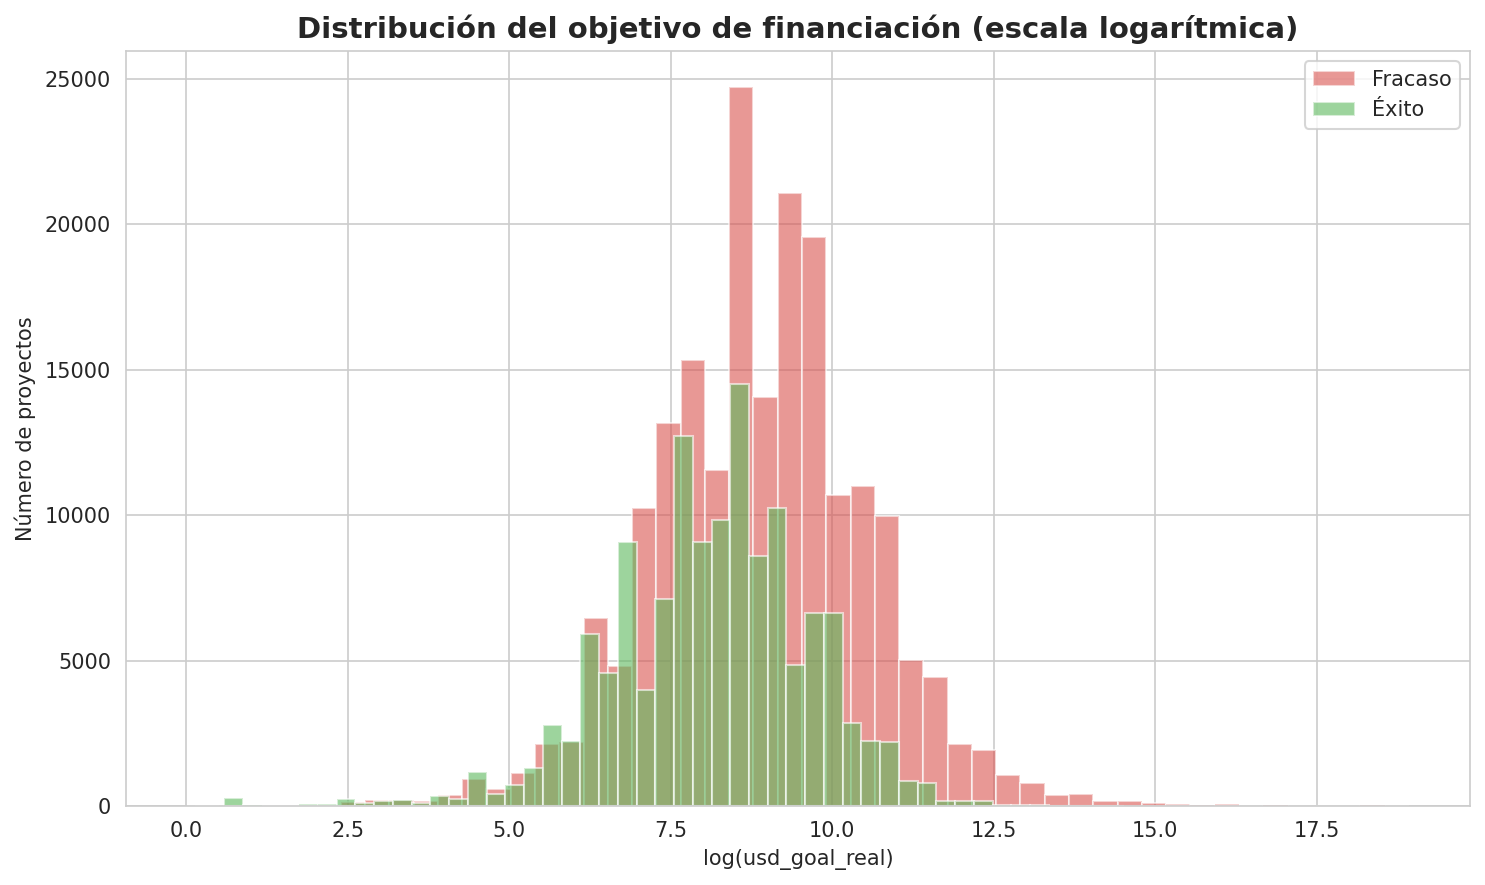

 Gráfico 3 guardado


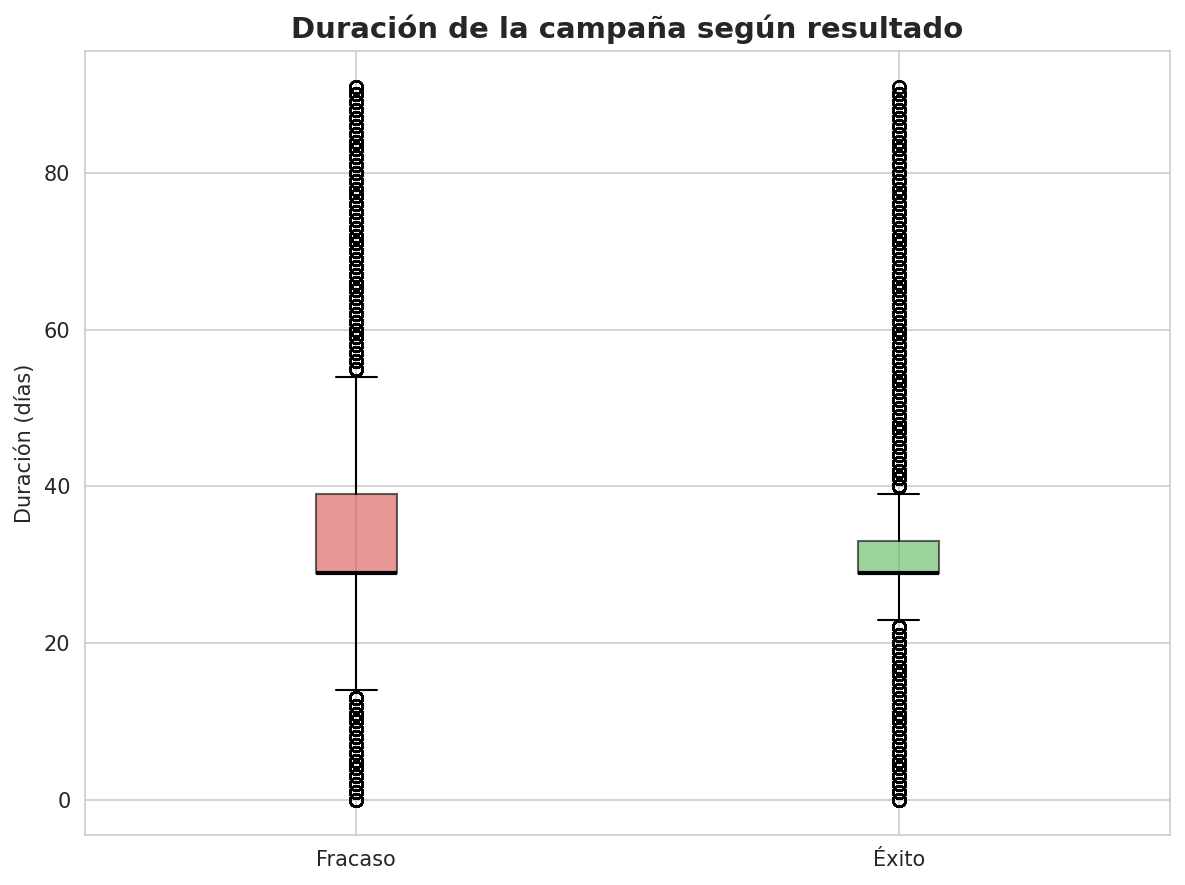

 Gráfico 4 guardado


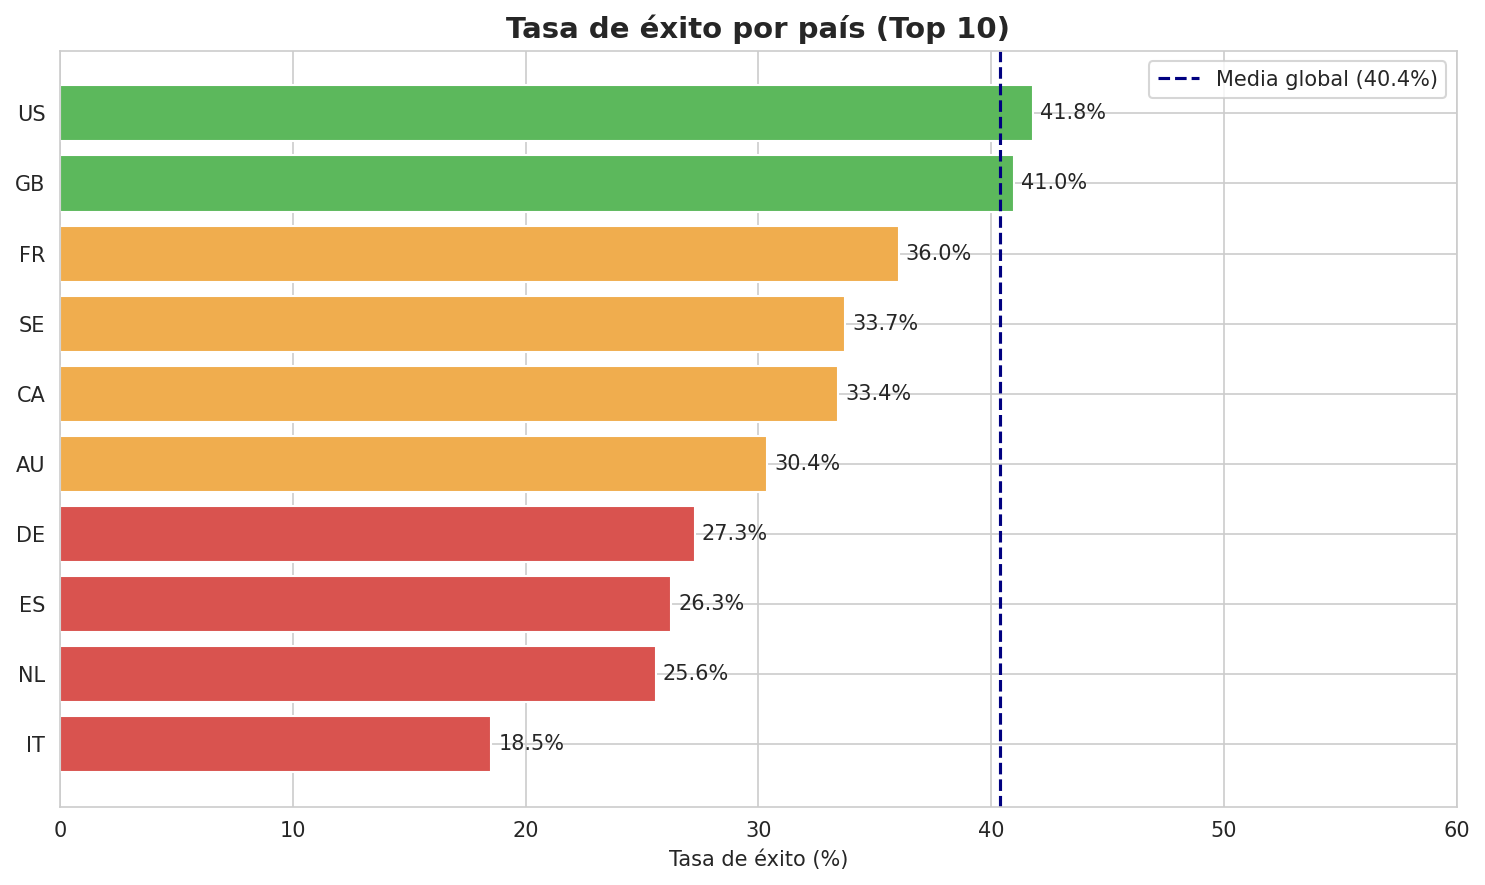

 Gráfico 5 guardado


In [9]:
# =============================================================================
# BLOQUE 3 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Estilo general de los gráficos
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

# -----------------------------------------------------------------------------
# 3.1 Distribución de la variable objetivo
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

conteo = df['target'].value_counts().sort_index()
colores = ['#d9534f', '#5cb85c']
bars = ax.bar(['Fracaso (0)', 'Éxito (1)'], conteo.values, color=colores, width=0.5)

for bar, valor in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2000,
            f'{valor:,}\n({valor/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Distribución de la variable objetivo', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de proyectos')
ax.set_ylim(0, max(conteo.values) * 1.15)
plt.tight_layout()
plt.savefig('eda_01_distribucion_objetivo.png', dpi=150)
plt.show()
print(" Gráfico 1 guardado")

# -----------------------------------------------------------------------------
# 3.2 Tasa de éxito por categoría principal
# -----------------------------------------------------------------------------

tasa_categoria = df.groupby('main_category')['target'].mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(10, 7))

colores_cat = ['#5cb85c' if x >= 40 else '#f0ad4e' if x >= 30 else '#d9534f'
               for x in tasa_categoria.values]

bars = ax.barh(tasa_categoria.index, tasa_categoria.values, color=colores_cat)

for bar, valor in zip(bars, tasa_categoria.values):
    ax.text(valor + 0.5, bar.get_y() + bar.get_height()/2,
            f'{valor:.1f}%', va='center', fontsize=10)

ax.axvline(x=40.4, color='navy', linestyle='--', linewidth=1.5, label='Media global (40.4%)')
ax.set_title('Tasa de éxito por categoría principal', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de éxito (%)')
ax.set_xlim(0, 80)
ax.legend()
plt.tight_layout()
plt.savefig('eda_02_tasa_categoria.png', dpi=150)
plt.show()
print(" Gráfico 2 guardado")

# -----------------------------------------------------------------------------
# 3.3 Distribución del objetivo de financiación (log_goal)
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df[df['target']==0]['log_goal'], bins=50, alpha=0.6,
        color='#d9534f', label='Fracaso')
ax.hist(df[df['target']==1]['log_goal'], bins=50, alpha=0.6,
        color='#5cb85c', label='Éxito')

ax.set_title('Distribución del objetivo de financiación (escala logarítmica)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('log(usd_goal_real)')
ax.set_ylabel('Número de proyectos')
ax.legend()
plt.tight_layout()
plt.savefig('eda_03_distribucion_goal.png', dpi=150)
plt.show()
print(" Gráfico 3 guardado")

# -----------------------------------------------------------------------------
# 3.4 Duración de la campaña por resultado
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

datos_boxplot = [df[df['target']==0]['duracion_dias'],
                 df[df['target']==1]['duracion_dias']]

bp = ax.boxplot(datos_boxplot, labels=['Fracaso', 'Éxito'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

bp['boxes'][0].set_facecolor('#d9534f')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#5cb85c')
bp['boxes'][1].set_alpha(0.6)

ax.set_title('Duración de la campaña según resultado', fontsize=14, fontweight='bold')
ax.set_ylabel('Duración (días)')
plt.tight_layout()
plt.savefig('eda_04_duracion_campaña.png', dpi=150)
plt.show()
print(" Gráfico 4 guardado")

# -----------------------------------------------------------------------------
# 3.5 Tasa de éxito por país (top 10)
# -----------------------------------------------------------------------------

top_paises = df['country'].value_counts().head(10).index
df_paises = df[df['country'].isin(top_paises)]
tasa_paises = df_paises.groupby('country')['target'].mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(10, 6))

colores_pais = ['#5cb85c' if x >= 40 else '#f0ad4e' if x >= 30 else '#d9534f'
                for x in tasa_paises.values]

bars = ax.barh(tasa_paises.index, tasa_paises.values, color=colores_pais)

for bar, valor in zip(bars, tasa_paises.values):
    ax.text(valor + 0.3, bar.get_y() + bar.get_height()/2,
            f'{valor:.1f}%', va='center', fontsize=10)

ax.axvline(x=40.4, color='navy', linestyle='--', linewidth=1.5, label='Media global (40.4%)')
ax.set_title('Tasa de éxito por país (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de éxito (%)')
ax.set_xlim(0, 60)
ax.legend()
plt.tight_layout()
plt.savefig('eda_05_tasa_paises.png', dpi=150)
plt.show()
print(" Gráfico 5 guardado")

Bloque 3 — Análisis exploratorio visualHe generado cinco gráficos para visualizar los patrones más relevantes del dataset. El más llamativo es el de la tasa de éxito por categoría, donde hay diferencias enormes: Dance alcanza un 65,4% de éxito mientras que Technology se queda en un 23,8%, una diferencia de más de 40 puntos porcentuales. Las categorías artísticas y culturales como Dance, Theater y Comics tienen tasas muy superiores a las categorías con mayor componente tecnológico o de producto físico. En cuanto a los países, Estados Unidos y Reino Unido lideran con tasas del 41,8% y 41,0% respectivamente, mientras que Italia se queda en un 18,5%. Estos gráficos los incluiré directamente en el documento como figuras.

In [10]:
# =============================================================================
# BLOQUE 4 — PREPROCESAMIENTO Y DIVISIÓN TRAIN/TEST
# =============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# 4.1 Selección de variables predictoras
# -----------------------------------------------------------------------------

variables = ['log_goal', 'duracion_dias', 'año_lanzamiento',
             'mes_lanzamiento', 'main_category', 'country']

df_modelo = df[variables + ['target']].copy()

print("=" * 60)
print("VARIABLES SELECCIONADAS")
print("=" * 60)
print(f"Variables predictoras: {variables}")
print(f"Dimensiones iniciales: {df_modelo.shape}")

# -----------------------------------------------------------------------------
# 4.2 Agrupación de países pequeños en 'Other'
# -----------------------------------------------------------------------------

conteo_paises = df_modelo['country'].value_counts()
paises_pequenos = conteo_paises[conteo_paises < 1000].index
df_modelo['country'] = df_modelo['country'].replace(paises_pequenos, 'Other')

print("\n" + "=" * 60)
print("AGRUPACIÓN DE PAÍSES")
print("=" * 60)
print(f"Países con menos de 1000 proyectos agrupados en 'Other': {len(paises_pequenos)}")
print(f"Países resultantes: {df_modelo['country'].nunique()}")
print(f"\nDistribución por país:")
print(df_modelo['country'].value_counts())

# -----------------------------------------------------------------------------
# 4.3 One-hot encoding de variables categóricas
# -----------------------------------------------------------------------------

df_modelo = pd.get_dummies(df_modelo, columns=['main_category', 'country'])

print("\n" + "=" * 60)
print("ONE-HOT ENCODING")
print("=" * 60)
print(f"Dimensiones tras encoding: {df_modelo.shape}")
print(f"\nValores nulos: {df_modelo.isnull().sum().sum()}")

# -----------------------------------------------------------------------------
# 4.4 División train/test
# -----------------------------------------------------------------------------

X = df_modelo.drop('target', axis=1)
y = df_modelo['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("DIVISIÓN TRAIN / TEST")
print("=" * 60)
print(f"Entrenamiento: {X_train.shape[0]:,} observaciones ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Prueba:        {X_test.shape[0]:,} observaciones ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribución en prueba:")
print(y_test.value_counts(normalize=True).round(3))

# -----------------------------------------------------------------------------
# 4.5 Escalado de variables numéricas para regresión logística
# -----------------------------------------------------------------------------

# El escalado solo se aplica a la regresión logística
# El resto de modelos no lo necesitan
variables_numericas = ['log_goal', 'duracion_dias', 'año_lanzamiento', 'mes_lanzamiento']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[variables_numericas] = scaler.fit_transform(X_train[variables_numericas])
X_test_scaled[variables_numericas]  = scaler.transform(X_test[variables_numericas])

print("\n" + "=" * 60)
print("ESCALADO DE VARIABLES NUMÉRICAS (para Regresión Logística)")
print("=" * 60)
print(f"Variables escaladas: {variables_numericas}")
print(f"\nEstadísticos tras escalado (X_train_scaled):")
print(X_train_scaled[variables_numericas].describe().round(3))

VARIABLES SELECCIONADAS
Variables predictoras: ['log_goal', 'duracion_dias', 'año_lanzamiento', 'mes_lanzamiento', 'main_category', 'country']
Dimensiones iniciales: (331675, 7)

AGRUPACIÓN DE PAÍSES
Países con menos de 1000 proyectos agrupados en 'Other': 11
Países resultantes: 13

Distribución por país:
country
US       261360
GB        29454
CA        12370
AU         6616
Other      5072
DE         3436
FR         2520
NL         2411
IT         2369
ES         1873
SE         1509
MX         1411
NZ         1274
Name: count, dtype: int64

ONE-HOT ENCODING
Dimensiones tras encoding: (331675, 33)

Valores nulos: 0

DIVISIÓN TRAIN / TEST
Entrenamiento: 265,340 observaciones (80%)
Prueba:        66,335 observaciones (20%)

Distribución en entrenamiento:
target
0    0.596
1    0.404
Name: proportion, dtype: float64

Distribución en prueba:
target
0    0.596
1    0.404
Name: proportion, dtype: float64

ESCALADO DE VARIABLES NUMÉRICAS (para Regresión Logística)
Variables escaladas: ['log

Bloque 4 — Preprocesamiento y división train/test
Aquí he preparado los datos para que los modelos los puedan consumir. Inicialmente tenía cuatro variables predictoras pero tras una primera prueba decidí añadir el año y el mes de lanzamiento, ya que los datos mostraban variaciones relevantes en la tasa de éxito a lo largo del tiempo. Esta decisión resultó acertada, mejorando el ROC-AUC de XGBoost de 0,711 a 0,725. En total el modelo trabaja con seis variables predictoras: objetivo de financiación en escala logarítmica, duración en días, año de lanzamiento, mes de lanzamiento, categoría principal y país de origen.
He agrupado los países con menos de 1.000 proyectos en una categoría "Other" para reducir ruido, quedando 13 grupos de países. Después he aplicado one-hot encoding a las variables categóricas, lo que hace que el dataset pase de 6 columnas a 33. Por último he dividido los datos en entrenamiento (80%, 265.340 observaciones) y prueba (20%, 66.335 observaciones) con estratificación para mantener la misma proporción de clases en ambos conjuntos.
Adicionalmente he aplicado escalado de las variables numéricas mediante StandardScaler para la regresión logística, ya que este modelo es sensible a la escala de las variables y sin este paso los resultados podían estar penalizados artificialmente. El resto de modelos no requieren escalado.


In [11]:
# =============================================================================
# BLOQUE 5 — ENTRENAMIENTO DE LOS MODELOS
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
import numpy as np

# -----------------------------------------------------------------------------
# 5.1 Búsqueda del max_depth óptimo — Árbol de Decisión
# -----------------------------------------------------------------------------

print("=" * 60)
print("BÚSQUEDA DE MAX_DEPTH ÓPTIMO — Árbol de Decisión")
print("=" * 60)

profundidades = range(3, 16)
scores_dt = []

for depth in profundidades:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    score = cross_val_score(dt, X_train, y_train, cv=5,
                            scoring='roc_auc', n_jobs=-1).mean()
    scores_dt.append(score)
    print(f"  max_depth={depth:2d} — ROC-AUC: {score:.4f}")

mejor_depth = profundidades[scores_dt.index(max(scores_dt))]
print(f"\n Mejor max_depth: {mejor_depth} (ROC-AUC: {max(scores_dt):.4f})")

# -----------------------------------------------------------------------------
# 5.2 Búsqueda de hiperparámetros — Random Forest (50% de los datos)
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("BÚSQUEDA DE HIPERPARÁMETROS — Random Forest")
print("=" * 60)
print("Usando el 50% de los datos de entrenamiento...")
print("Esto puede tardar entre 25-40 minutos...\n")

# Muestra del 50%
X_sample_rf = X_train.sample(frac=0.5, random_state=42)
y_sample_rf = y_train[X_sample_rf.index]

print(f"Observaciones para la búsqueda: {len(X_sample_rf):,}")

param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 15, None],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_sample_rf, y_sample_rf)
print(f"\n Mejores hiperparámetros Random Forest:")
for param, valor in rf_search.best_params_.items():
    print(f"  {param}: {valor}")
print(f"  ROC-AUC (CV): {rf_search.best_score_:.4f}")

# -----------------------------------------------------------------------------
# 5.3 Definición de los modelos
# -----------------------------------------------------------------------------

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión':   DecisionTreeClassifier(max_depth=mejor_depth, random_state=42),
    'Random Forest':       RandomForestClassifier(
                               **rf_search.best_params_,
                               random_state=42,
                               n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200,
                                         max_depth=5,
                                         learning_rate=0.1,
                                         subsample=0.8,
                                         colsample_bytree=0.8,
                                         random_state=42,
                                         eval_metric='logloss')
}

print("\n" + "=" * 60)
print("MODELOS DEFINIDOS")
print("=" * 60)
for nombre in modelos:
    print(f"   {nombre}")

# -----------------------------------------------------------------------------
# 5.4 Entrenamiento y evaluación
# -----------------------------------------------------------------------------

resultados = {}

print("\n" + "=" * 60)
print("ENTRENAMIENTO Y EVALUACIÓN")
print("=" * 60)

for nombre, modelo in modelos.items():
    print(f"\nEntrenando {nombre}...")

    if nombre == 'Regresión Logística':
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
        y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados[nombre] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    }
    print(f"   {nombre} completado")

# -----------------------------------------------------------------------------
# 5.5 Tabla comparativa de resultados
# -----------------------------------------------------------------------------

df_resultados = pd.DataFrame(resultados).T

print("\n" + "=" * 60)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 60)
print(df_resultados.to_string())

print("\n" + "=" * 60)
print("MEJOR MODELO POR MÉTRICA")
print("=" * 60)
for metrica in df_resultados.columns:
    mejor = df_resultados[metrica].idxmax()
    valor = df_resultados[metrica].max()
    print(f"  {metrica:12s}: {mejor} ({valor})")

BÚSQUEDA DE MAX_DEPTH ÓPTIMO — Árbol de Decisión
  max_depth= 3 — ROC-AUC: 0.6407
  max_depth= 4 — ROC-AUC: 0.6527
  max_depth= 5 — ROC-AUC: 0.6639
  max_depth= 6 — ROC-AUC: 0.6751
  max_depth= 7 — ROC-AUC: 0.6834
  max_depth= 8 — ROC-AUC: 0.6896
  max_depth= 9 — ROC-AUC: 0.6939
  max_depth=10 — ROC-AUC: 0.6965
  max_depth=11 — ROC-AUC: 0.6977
  max_depth=12 — ROC-AUC: 0.6969
  max_depth=13 — ROC-AUC: 0.6942
  max_depth=14 — ROC-AUC: 0.6897
  max_depth=15 — ROC-AUC: 0.6844

 Mejor max_depth: 11 (ROC-AUC: 0.6977)

BÚSQUEDA DE HIPERPARÁMETROS — Random Forest
Usando el 50% de los datos de entrenamiento...
Esto puede tardar entre 25-40 minutos...

Observaciones para la búsqueda: 132,670
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Mejores hiperparámetros Random Forest:
  n_estimators: 200
  min_samples_split: 5
  max_features: sqrt
  max_depth: 15
  ROC-AUC (CV): 0.7145

MODELOS DEFINIDOS
   Regresión Logística
   Árbol de Decisión
   Random Forest
   XGBoost

ENTRENAMIEN

Bloque 5 — Entrenamiento de los modelos
He entrenado los cuatro modelos: regresión logística, árbol de decisión, Random Forest y XGBoost. Para mejorar la calidad de los modelos he realizado una búsqueda de hiperparámetros en los tres modelos no lineales.
Para el árbol de decisión he buscado el valor óptimo de max_depth probando profundidades entre 3 y 15 mediante validación cruzada, obteniendo max_depth=11 como valor óptimo con un ROC-AUC de 0,6977.
Para Random Forest he aplicado RandomizedSearchCV sobre el 50% de los datos de entrenamiento (132.670 observaciones) por limitaciones computacionales, probando combinaciones de n_estimators, max_depth, min_samples_split y max_features. Los mejores hiperparámetros encontrados han sido n_estimators=200, max_depth=15, min_samples_split=5 y max_features=sqrt. Esta optimización ha supuesto una mejora muy significativa en el ROC-AUC del Random Forest, pasando de 0,665 a 0,718.
Para XGBoost he ajustado manualmente los hiperparámetros principales: n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.8 y colsample_bytree=0.8.
Los resultados muestran que XGBoost es el mejor modelo en términos globales con un ROC-AUC de 0,7252 y un F1-score de 0,5511. Sin embargo cada modelo destaca en una métrica concreta: Random Forest obtiene la mejor Precision (0,635), lo que significa que cuando predice éxito acierta más que ningún otro modelo, y el Árbol de Decisión obtiene el mejor Recall (0,497), siendo el que más proyectos exitosos reales detecta. Este trade-off entre Precision y Recall tiene implicaciones claras desde el punto de vista de negocio: un inversor preferiría un modelo con alta Precision para no apostar por proyectos que van a fracasar, mientras que un creador preferiría un modelo con alto Recall para no descartar proyectos que podrían tener éxito.

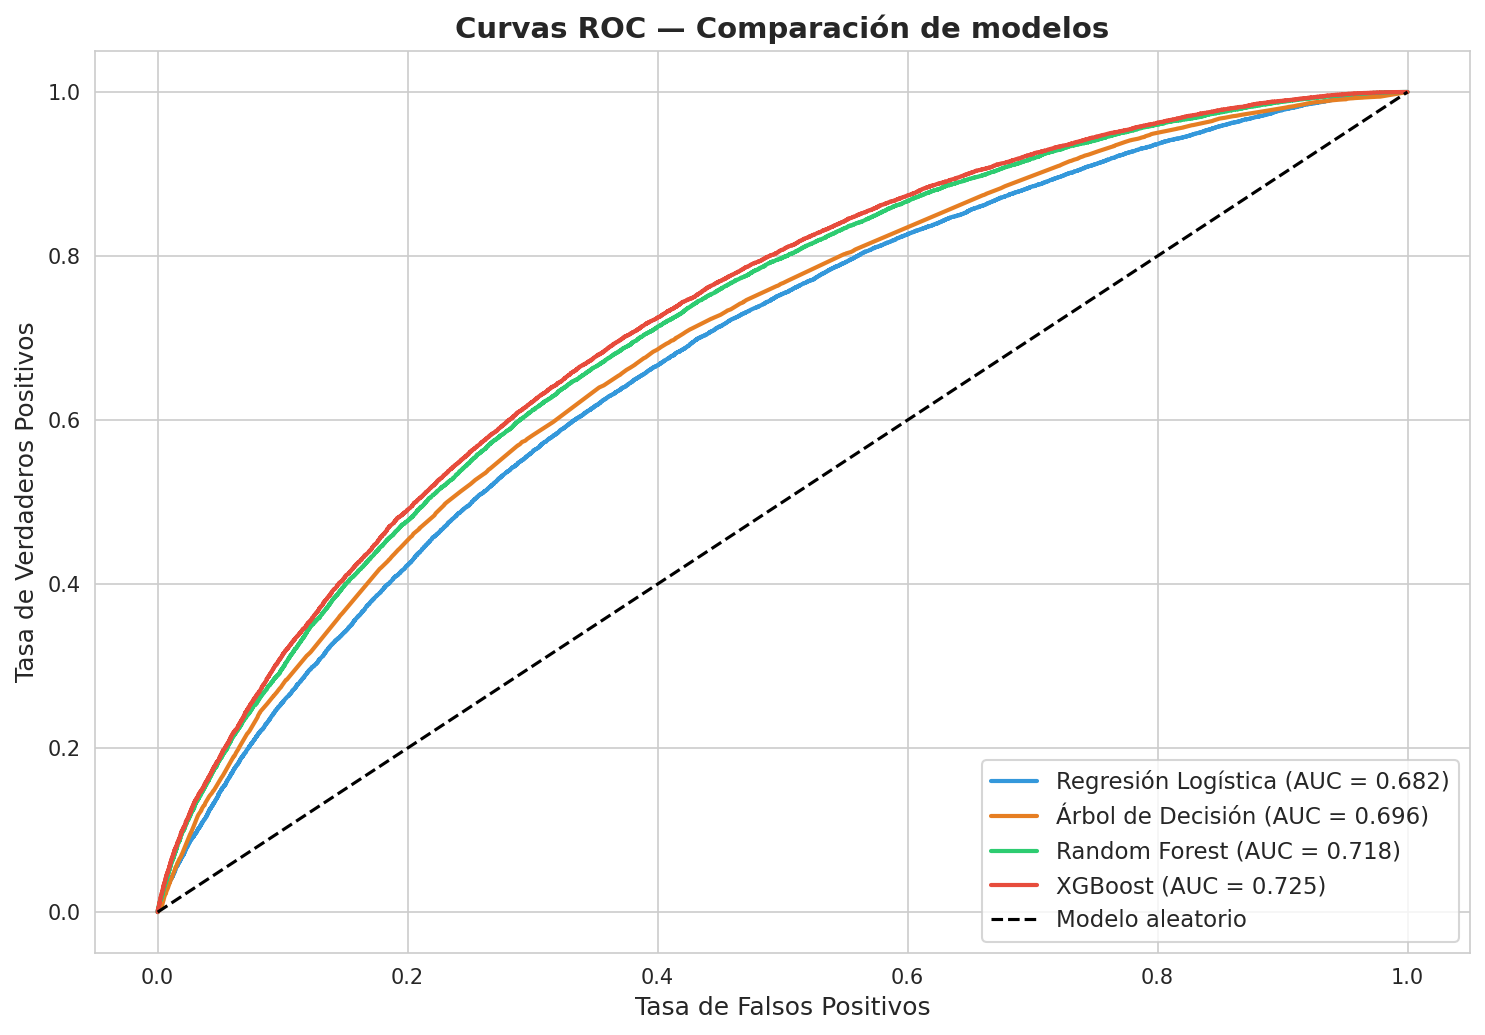

 Curvas ROC guardadas


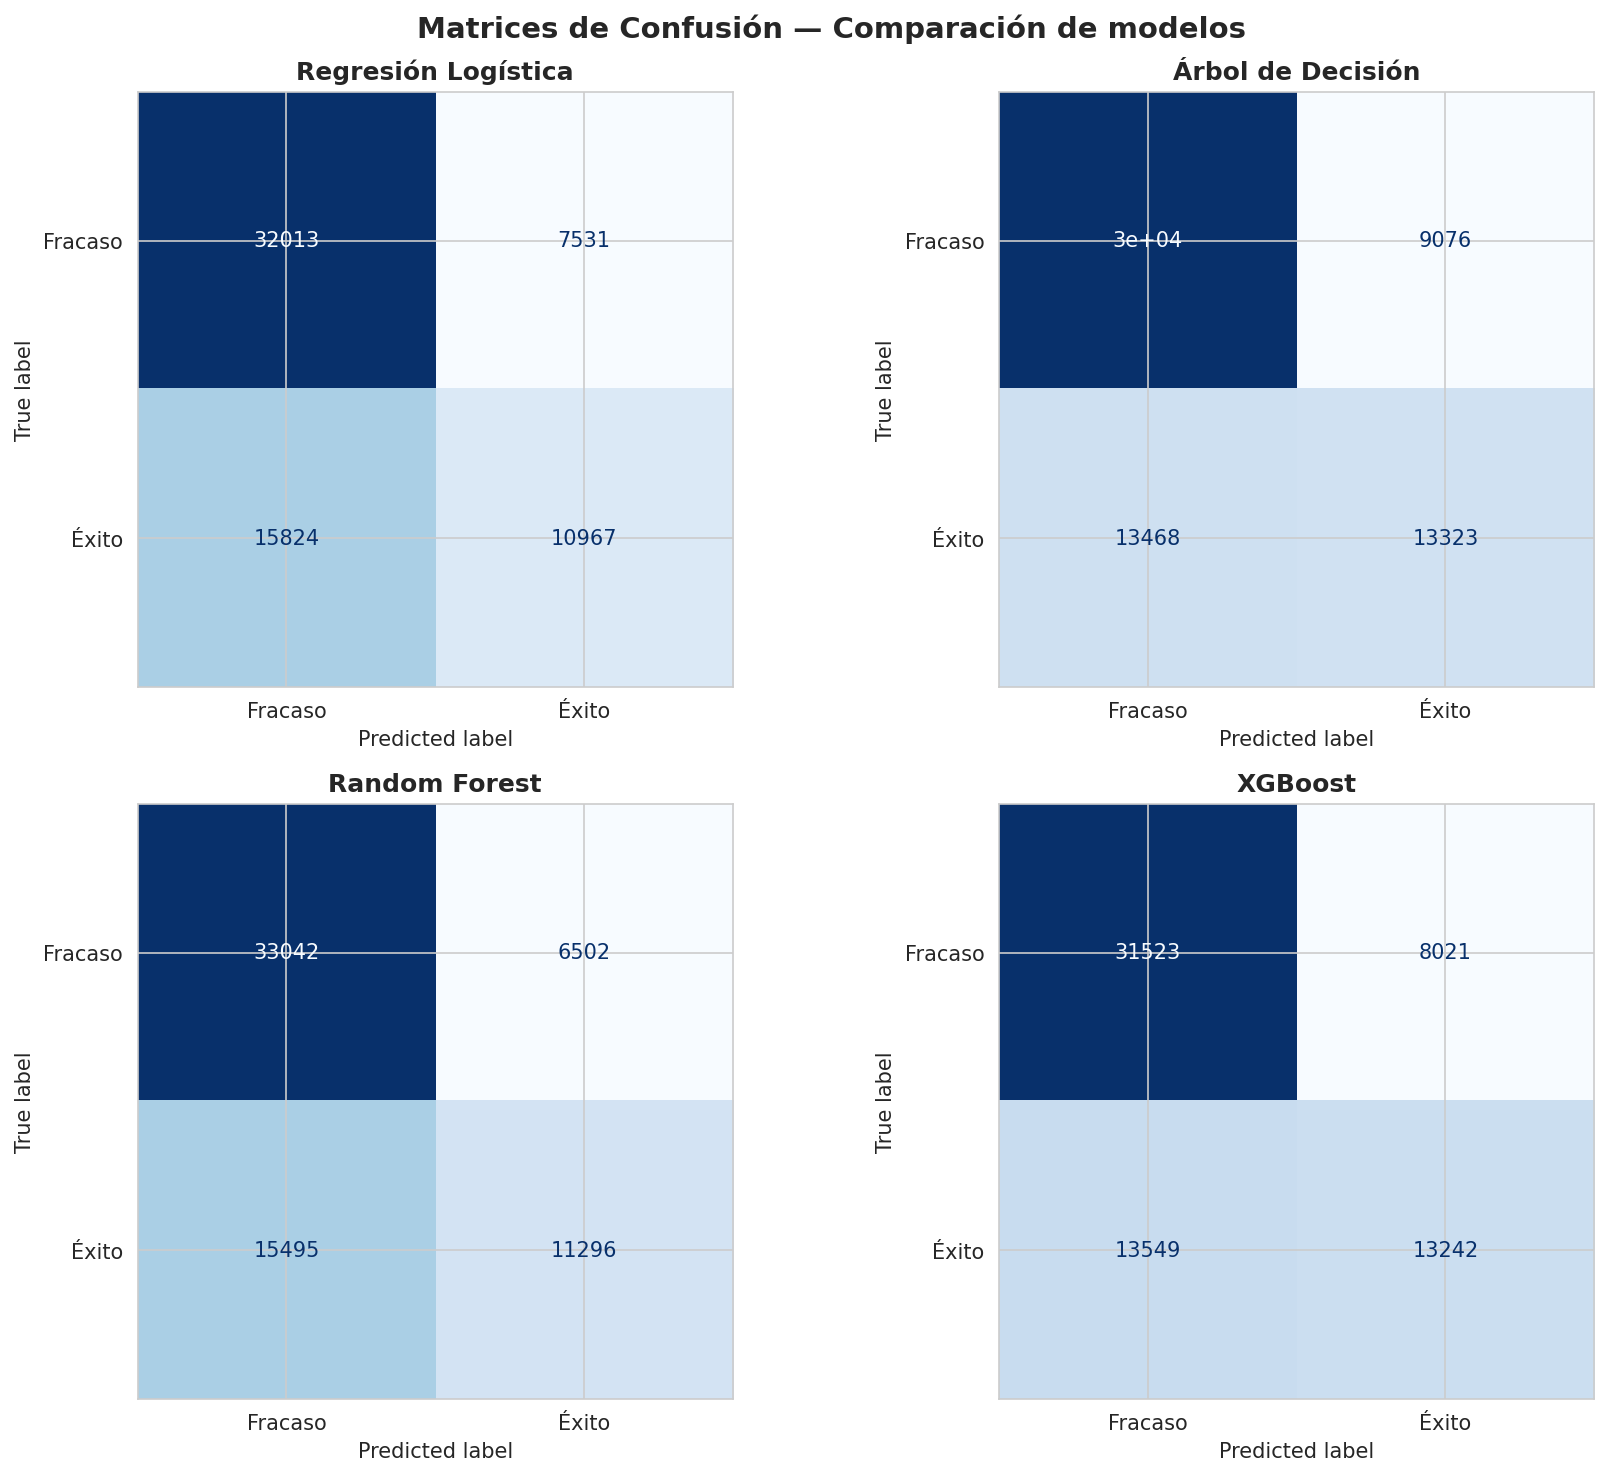

 Matrices de confusión guardadas

MATRICES DE CONFUSIÓN — VALORES NUMÉRICOS

Regresión Logística:
  Verdaderos Negativos (fracaso correcto):       32,013
  Falsos Positivos (fracaso como éxito):         7,531
  Falsos Negativos (éxito como fracaso):         15,824
  Verdaderos Positivos (éxito correcto):         10,967

Árbol de Decisión:
  Verdaderos Negativos (fracaso correcto):       30,468
  Falsos Positivos (fracaso como éxito):         9,076
  Falsos Negativos (éxito como fracaso):         13,468
  Verdaderos Positivos (éxito correcto):         13,323

Random Forest:
  Verdaderos Negativos (fracaso correcto):       33,042
  Falsos Positivos (fracaso como éxito):         6,502
  Falsos Negativos (éxito como fracaso):         15,495
  Verdaderos Positivos (éxito correcto):         11,296

XGBoost:
  Verdaderos Negativos (fracaso correcto):       31,523
  Falsos Positivos (fracaso como éxito):         8,021
  Falsos Negativos (éxito como fracaso):         13,549
  Verdaderos Positiv

In [12]:
# =============================================================================
# BLOQUE 6 — CURVAS ROC Y MATRICES DE CONFUSIÓN
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------------------------------------------------------
# 6.1 Curvas ROC
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 7))

colores = {
    'Regresión Logística': '#3498db',
    'Árbol de Decisión':   '#e67e22',
    'Random Forest':       '#2ecc71',
    'XGBoost':             '#e74c3c'
}

for nombre, modelo in modelos.items():
    if nombre == 'Regresión Logística':
        y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc:.3f})',
             color=colores[nombre], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatorio', linewidth=1.5)
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Curvas ROC — Comparación de modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150)
plt.show()
print(" Curvas ROC guardadas")

# -----------------------------------------------------------------------------
# 6.2 Matrices de confusión
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (nombre, modelo) in enumerate(modelos.items()):
    if nombre == 'Regresión Logística':
        y_pred = modelo.predict(X_test_scaled)
    else:
        y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Fracaso', 'Éxito'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(nombre, fontsize=12, fontweight='bold')

plt.suptitle('Matrices de Confusión — Comparación de modelos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150)
plt.show()
print(" Matrices de confusión guardadas")

# -----------------------------------------------------------------------------
# 6.3 Valores numéricos de las matrices de confusión
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("MATRICES DE CONFUSIÓN — VALORES NUMÉRICOS")
print("=" * 60)

for nombre, modelo in modelos.items():
    if nombre == 'Regresión Logística':
        y_pred = modelo.predict(X_test_scaled)
    else:
        y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{nombre}:")
    print(f"  Verdaderos Negativos (fracaso correcto):       {cm[0,0]:,}")
    print(f"  Falsos Positivos (fracaso como éxito):         {cm[0,1]:,}")
    print(f"  Falsos Negativos (éxito como fracaso):         {cm[1,0]:,}")
    print(f"  Verdaderos Positivos (éxito correcto):         {cm[1,1]:,}")

Bloque 6 — Curvas ROC, matrices de confusión y gráfico comparativo
He generado las curvas ROC, las matrices de confusión y un gráfico comparativo de todas las métricas para analizar el rendimiento de cada modelo de forma visual. Las curvas ROC confirman la superioridad de XGBoost con un AUC de 0,725, seguido de Random Forest con 0,718, Árbol de Decisión con 0,696 y Regresión Logística con 0,682.
Las matrices de confusión muestran comportamientos muy distintos entre modelos. XGBoost es el más equilibrado con 31.523 verdaderos negativos y 13.242 verdaderos positivos. Random Forest es el más conservador, clasificando correctamente 33.042 fracasos pero dejando sin detectar 15.495 éxitos, lo que explica su baja Recall. El Árbol de Decisión detecta más éxitos reales (13.323) pero a costa de más falsos positivos (9.076). La Regresión Logística falla notablemente con los éxitos, dejando sin detectar 15.824 proyectos exitosos.

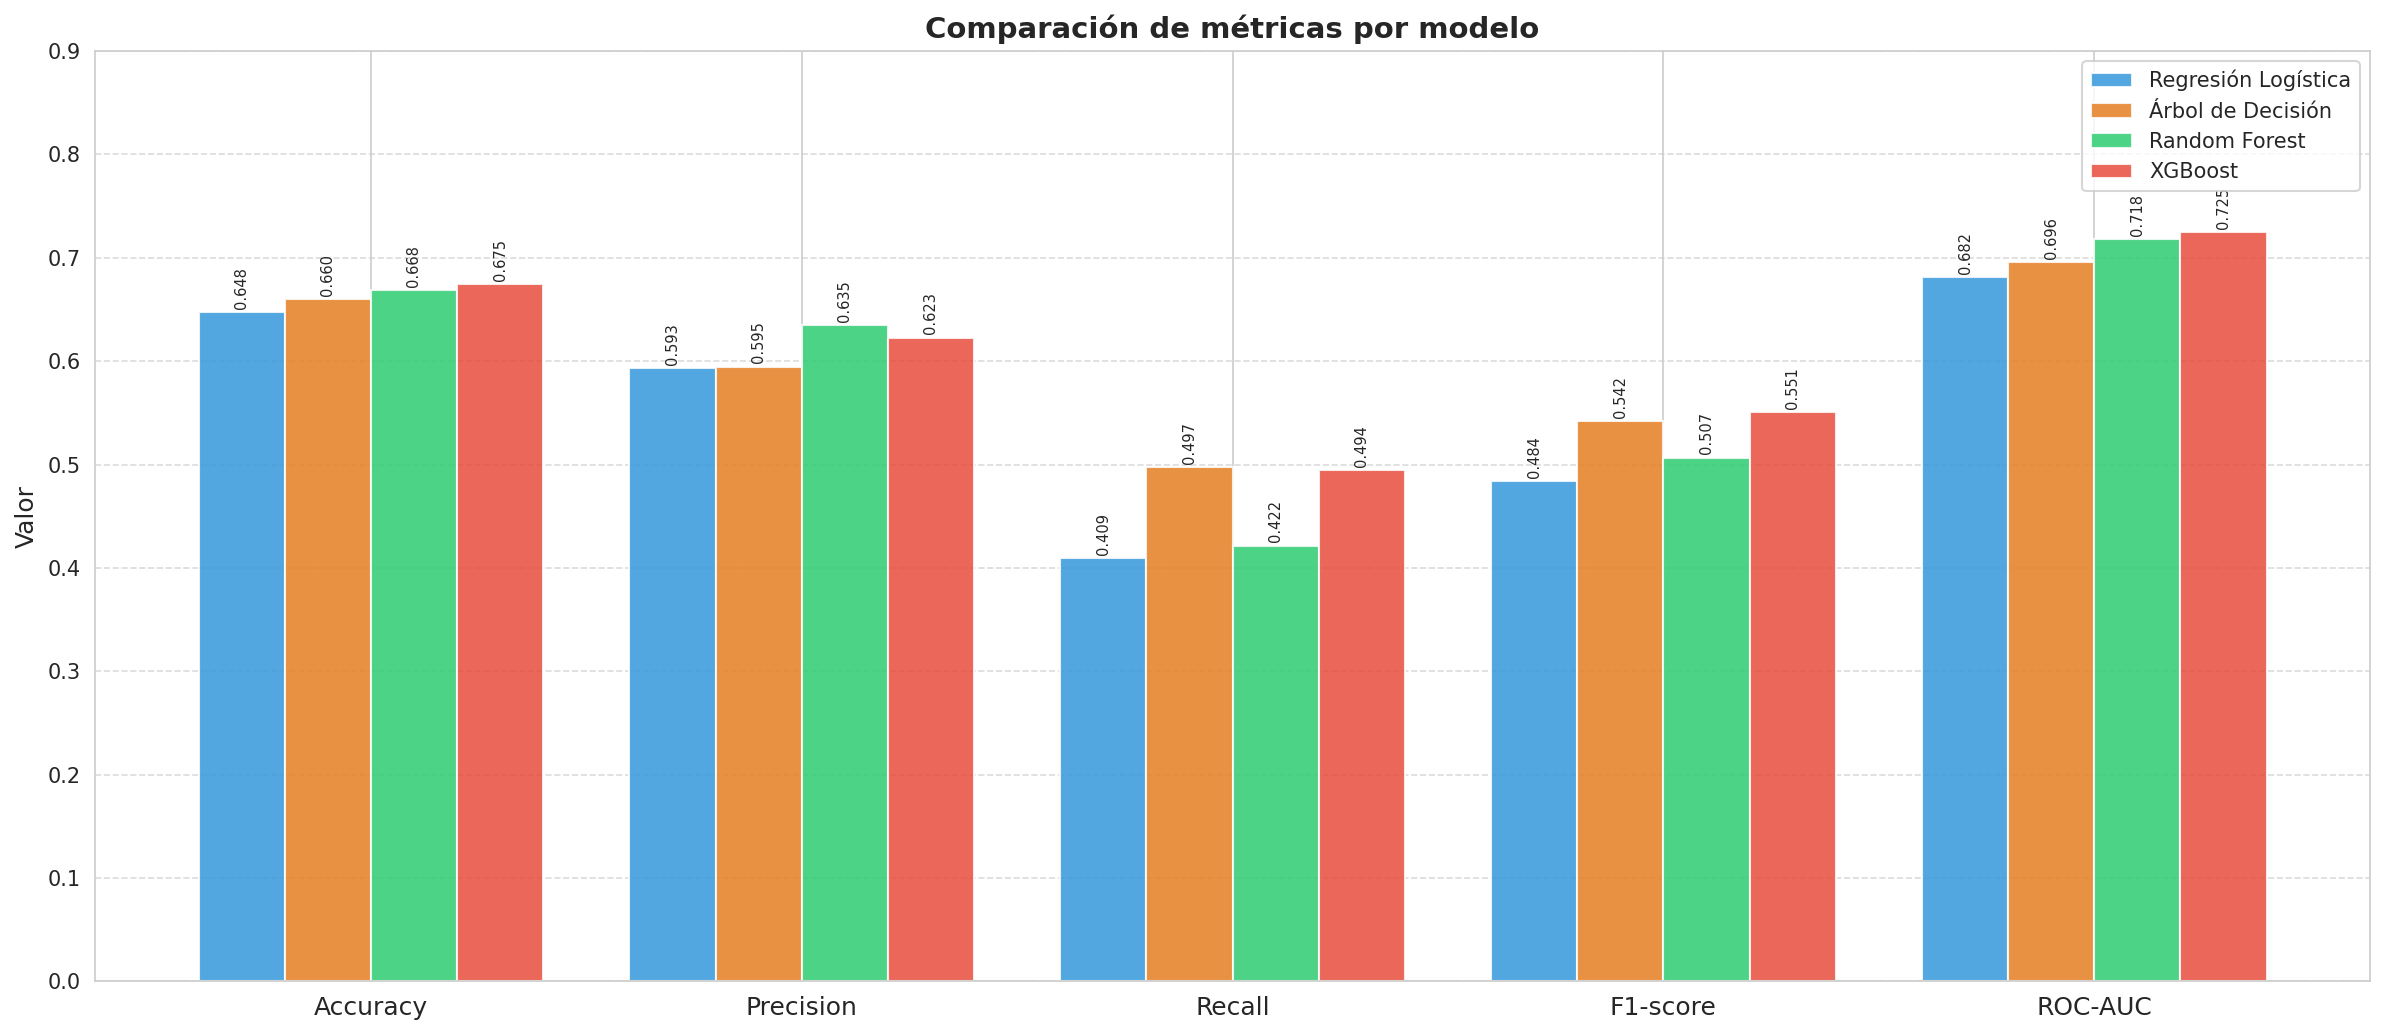

 Gráfico comparativo de métricas guardado


In [13]:
# =============================================================================
# BLOQUE 6B — GRÁFICO COMPARATIVO DE MÉTRICAS
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# Gráfico de barras agrupadas — comparación de métricas
# -----------------------------------------------------------------------------

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
modelos_nombres = list(df_resultados.index)
colores = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']

x = np.arange(len(metricas))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))

for i, (nombre, color) in enumerate(zip(modelos_nombres, colores)):
    valores = df_resultados.loc[nombre, metricas].values.astype(float)
    bars = ax.bar(x + i * width, valores, width,
                  label=nombre, color=color, alpha=0.85)
    for bar, valor in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{valor:.3f}',
                ha='center', va='bottom',
                fontsize=7, rotation=90)

ax.set_title('Comparación de métricas por modelo',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_ylim(0, 0.90)
ax.legend(loc='upper right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150)
plt.show()
print(" Gráfico comparativo de métricas guardado")

Bloque 6 — Curvas ROC, matrices de confusión y gráfico comparativo de métricas
He generado tres visualizaciones para analizar el rendimiento de los modelos. Las curvas ROC confirman la superioridad de XGBoost con un AUC de 0,725, seguido de Random Forest con 0,718, Árbol de Decisión con 0,696 y Regresión Logística con 0,682.
Las matrices de confusión muestran que XGBoost es el más equilibrado, Random Forest es el más conservador (clasifica bien los fracasos pero se le escapan muchos éxitos), el Árbol de Decisión detecta más éxitos pero comete más falsos positivos, y la Regresión Logística falla notablemente con los proyectos exitosos.
El gráfico comparativo permite ver de un vistazo que XGBoost domina en Accuracy, F1-score y ROC-AUC, Random Forest destaca en Precision y el Árbol de Decisión en Recall. Este trade-off tiene implicaciones de negocio claras: un inversor preferiría Random Forest para no apostar por proyectos que van a fracasar, mientras que un creador preferiría el Árbol de Decisión para no descartar proyectos con potencial.

In [14]:
# =============================================================================
# BLOQUE 7 — VALIDACIÓN CRUZADA K=5
# =============================================================================

from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados_cv = {}

print("=" * 60)
print("VALIDACIÓN CRUZADA K=5")
print("=" * 60)
print("Esto puede tardar varios minutos...\n")

for nombre, modelo in modelos.items():
    print(f"Validando {nombre}...")

    # Para regresión logística incluimos el escalado dentro del pipeline
    if nombre == 'Regresión Logística':
        pipeline = make_pipeline(StandardScaler(), modelo)
        cv_results = cross_validate(
            pipeline, X, y,
            cv=5,
            scoring=scoring,
            n_jobs=-1
        )
    else:
        cv_results = cross_validate(
            modelo, X, y,
            cv=5,
            scoring=scoring,
            n_jobs=-1
        )

    resultados_cv[nombre] = {
        'Accuracy':  round(cv_results['test_accuracy'].mean(), 4),
        'Precision': round(cv_results['test_precision'].mean(), 4),
        'Recall':    round(cv_results['test_recall'].mean(), 4),
        'F1-score':  round(cv_results['test_f1'].mean(), 4),
        'ROC-AUC':   round(cv_results['test_roc_auc'].mean(), 4)
    }
    print(f"   {nombre} completado")

df_cv = pd.DataFrame(resultados_cv).T

print("\n" + "=" * 60)
print("RESULTADOS VALIDACIÓN CRUZADA K=5")
print("=" * 60)
print(df_cv.to_string())

print("\n" + "=" * 60)
print("COMPARACIÓN PRUEBA vs VALIDACIÓN CRUZADA (ROC-AUC)")
print("=" * 60)
for nombre in modelos.keys():
    auc_test = df_resultados.loc[nombre, 'ROC-AUC']
    auc_cv   = df_cv.loc[nombre, 'ROC-AUC']
    diff     = auc_cv - auc_test
    print(f"{nombre:25s}: Test={auc_test:.4f} | CV={auc_cv:.4f} | Diff={diff:+.4f}")

print("\n" + "=" * 60)
print("MEJOR MODELO POR MÉTRICA (Validación Cruzada)")
print("=" * 60)
for metrica in df_cv.columns:
    mejor = df_cv[metrica].idxmax()
    valor = df_cv[metrica].max()
    print(f"  {metrica:12s}: {mejor} ({valor})")

VALIDACIÓN CRUZADA K=5
Esto puede tardar varios minutos...

Validando Regresión Logística...
   Regresión Logística completado
Validando Árbol de Decisión...
   Árbol de Decisión completado
Validando Random Forest...
   Random Forest completado
Validando XGBoost...
   XGBoost completado

RESULTADOS VALIDACIÓN CRUZADA K=5
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Regresión Logística    0.6493     0.5966  0.4065    0.4835   0.6835
Árbol de Decisión      0.6605     0.5992  0.4814    0.5338   0.6983
Random Forest          0.6682     0.6359  0.4177    0.5042   0.7185
XGBoost                0.6768     0.6278  0.4907    0.5508   0.7273

COMPARACIÓN PRUEBA vs VALIDACIÓN CRUZADA (ROC-AUC)
Regresión Logística      : Test=0.6817 | CV=0.6835 | Diff=+0.0018
Árbol de Decisión        : Test=0.6958 | CV=0.6983 | Diff=+0.0025
Random Forest            : Test=0.7180 | CV=0.7185 | Diff=+0.0005
XGBoost                  : Test=0.7252 | CV=0.7273 | Diff=+0.0021

MEJOR MODELO POR MÉT

Bloque 7 — Validación cruzada k=5
Para asegurarme de que los resultados no dependen de una partición concreta del dataset he aplicado validación cruzada con 5 folds. Para la regresión logística he incluido el escalado dentro del pipeline de validación cruzada, lo que garantiza que el escalado se aplica correctamente en cada fold sin filtración de información entre conjuntos.
Los resultados son prácticamente idénticos a los del conjunto de prueba, con diferencias máximas de 0,0025 puntos en el ROC-AUC. Esto confirma que todos los modelos generalizan bien y no están sobreajustados. XGBoost mantiene su posición como mejor modelo con un ROC-AUC de 0,7273 en validación cruzada, y Random Forest confirma su mejora con un 0,7185, muy cerca de XGBoost.

TOP 10 VARIABLES MÁS IMPORTANTES — Random Forest
log_goal                    0.3671
duracion_dias               0.2105
año_lanzamiento             0.0962
mes_lanzamiento             0.0578
main_category_Music         0.0377
main_category_Technology    0.0316
main_category_Theater       0.0307
main_category_Comics        0.0216
main_category_Fashion       0.0197
main_category_Food          0.0176


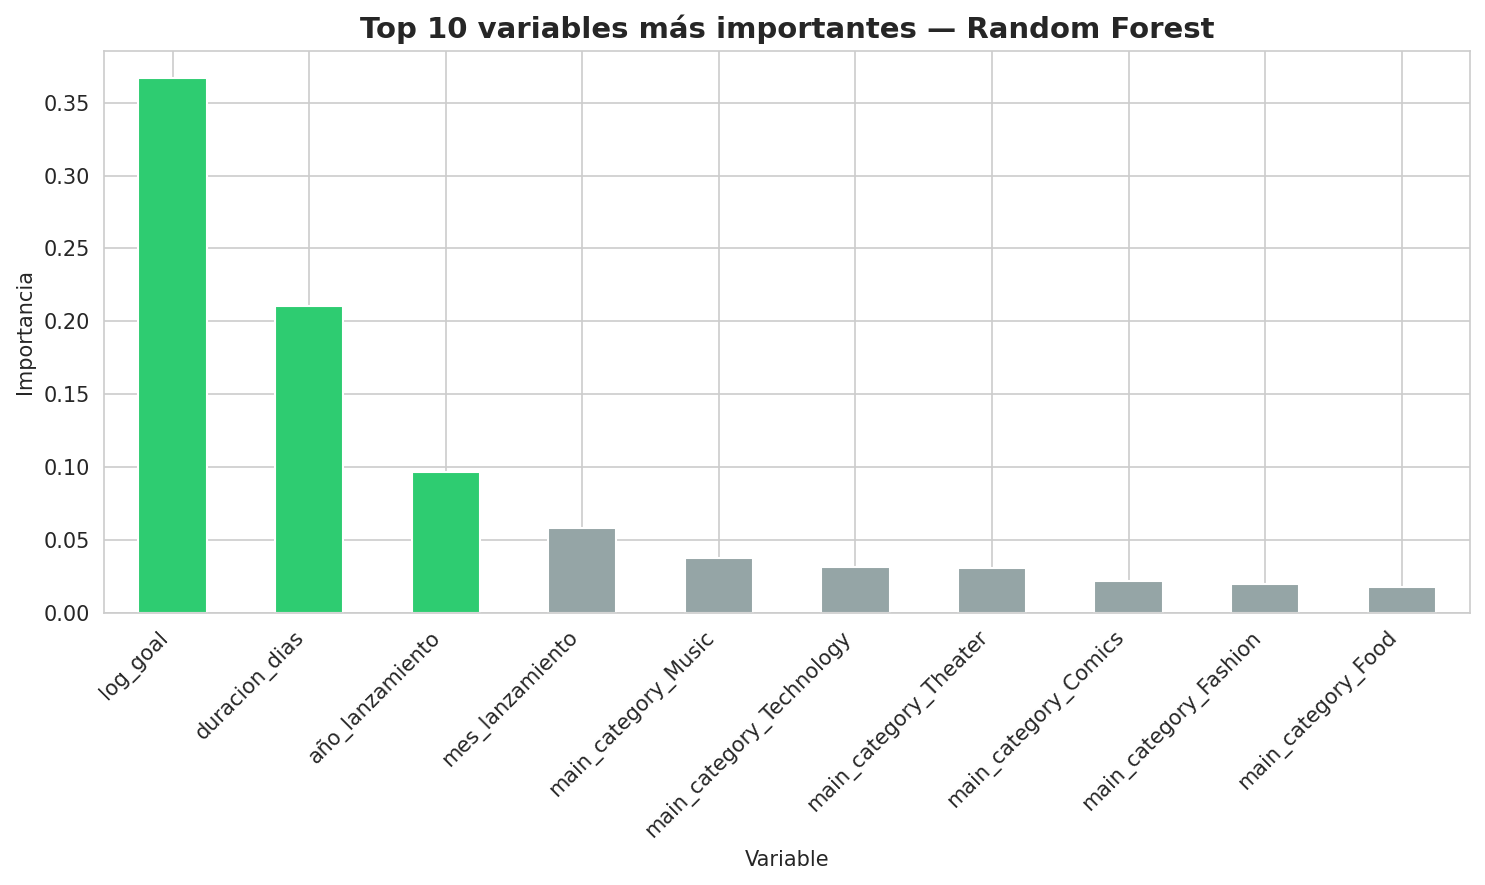

 Gráfico Random Forest guardado

TOP 10 VARIABLES MÁS IMPORTANTES — XGBoost
main_category_Theater       0.1005
main_category_Comics        0.0844
main_category_Fashion       0.0783
main_category_Music         0.0772
main_category_Crafts        0.0724
log_goal                    0.0549
main_category_Publishing    0.0542
main_category_Technology    0.0539
main_category_Dance         0.0525
main_category_Food          0.0500


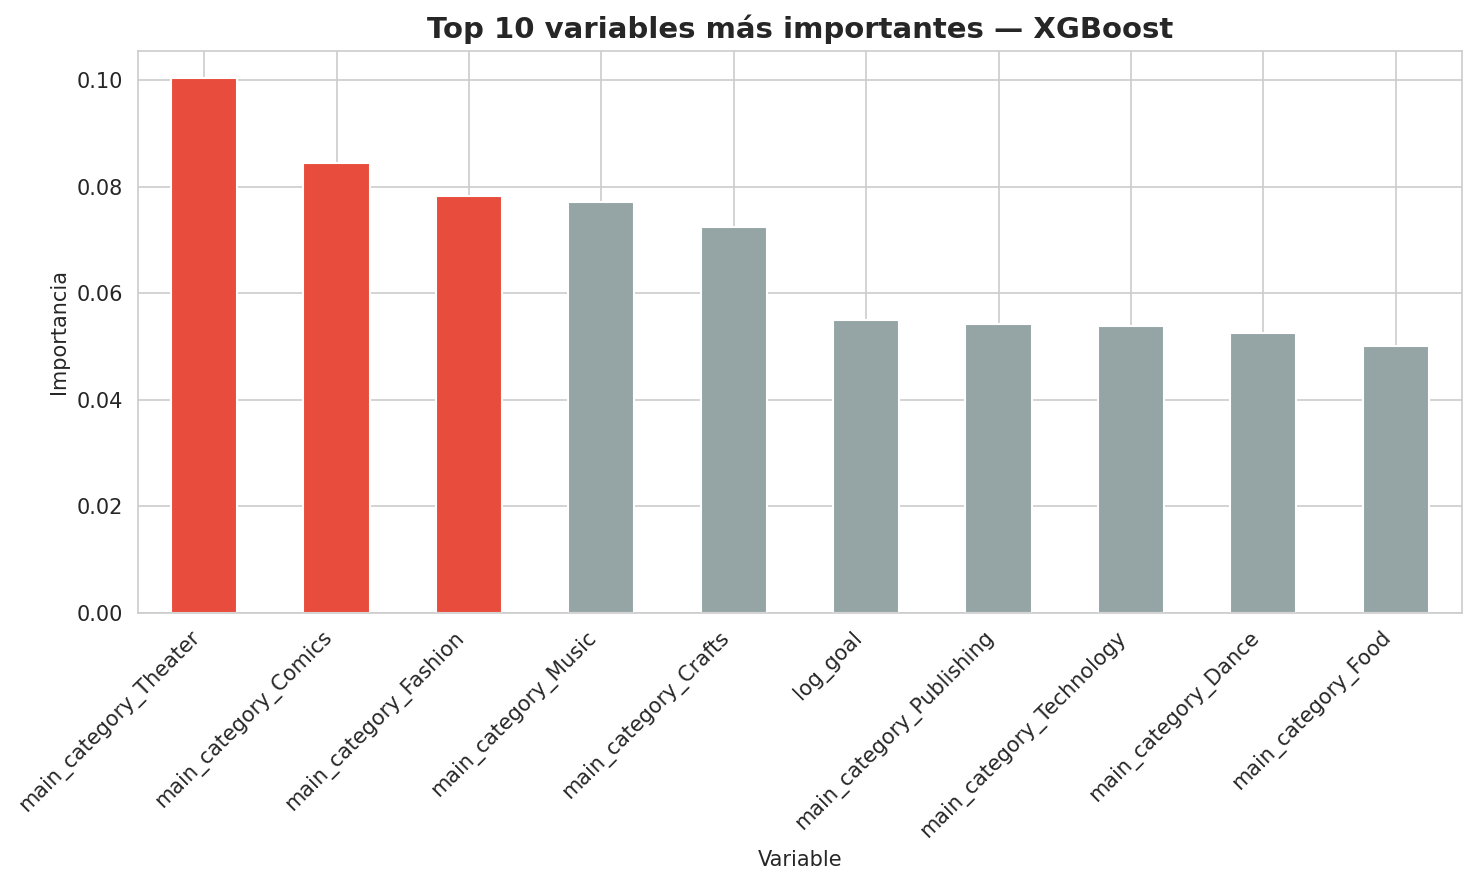

 Gráfico XGBoost guardado

COMPARACIÓN IMPORTANCIAS — RF vs XGBoost (Top 10)
                          Random Forest  XGBoost
log_goal                         0.3671   0.0549
duracion_dias                    0.2105   0.0367
año_lanzamiento                  0.0962   0.0295
mes_lanzamiento                  0.0578   0.0072
main_category_Music              0.0377   0.0772
main_category_Technology         0.0316   0.0539
main_category_Theater            0.0307   0.1005
main_category_Comics             0.0216   0.0844
main_category_Fashion            0.0197   0.0783
main_category_Food               0.0176   0.0500


In [16]:
# =============================================================================
# BLOQUE 8 — IMPORTANCIA DE VARIABLES
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# 8.1 Importancia de variables — Random Forest
# -----------------------------------------------------------------------------

importancias_rf = pd.Series(
    modelos['Random Forest'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("=" * 60)
print("TOP 10 VARIABLES MÁS IMPORTANTES — Random Forest")
print("=" * 60)
print(importancias_rf.head(10).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#2ecc71' if i < 3 else '#95a5a6' for i in range(10)]
importancias_rf.head(10).plot(kind='bar', ax=ax, color=colores)
ax.set_title('Top 10 variables más importantes — Random Forest',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Importancia')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('importancia_rf.png', dpi=150)
plt.show()
print(" Gráfico Random Forest guardado")

# -----------------------------------------------------------------------------
# 8.2 Importancia de variables — XGBoost
# -----------------------------------------------------------------------------

importancias_xgb = pd.Series(
    modelos['XGBoost'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\n" + "=" * 60)
print("TOP 10 VARIABLES MÁS IMPORTANTES — XGBoost")
print("=" * 60)
print(importancias_xgb.head(10).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#e74c3c' if i < 3 else '#95a5a6' for i in range(10)]
importancias_xgb.head(10).plot(kind='bar', ax=ax, color=colores)
ax.set_title('Top 10 variables más importantes — XGBoost',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Importancia')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('importancia_xgb.png', dpi=150)
plt.show()
print(" Gráfico XGBoost guardado")

# -----------------------------------------------------------------------------
# 8.3 Tabla comparativa corregida
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("COMPARACIÓN IMPORTANCIAS — RF vs XGBoost (Top 10)")
print("=" * 60)
comparacion = pd.DataFrame({
    'Random Forest': importancias_rf,
    'XGBoost':       importancias_xgb
}).sort_values('Random Forest', ascending=False).head(10)
print(comparacion.round(4).to_string())

Bloque 8 — Importancia de variables
He analizado la importancia de variables en Random Forest y XGBoost. Con los hiperparámetros optimizados, Random Forest ahora distribuye mejor la importancia entre todas las variables: log_goal sigue siendo la más importante con un 36,7%, seguido de duracion_dias con un 21,1% y año_lanzamiento con un 9,6%. Las categorías también ganan más peso que antes, especialmente Music, Technology y Theater. XGBoost sigue distribuyendo la importancia principalmente entre categorías, destacando Theater con un 10,05% y Comics con un 8,44%. La discrepancia entre modelos justifica el análisis SHAP del siguiente bloque.

ANÁLISIS SHAP — XGBoost
Calculando valores SHAP...
 Valores SHAP calculados


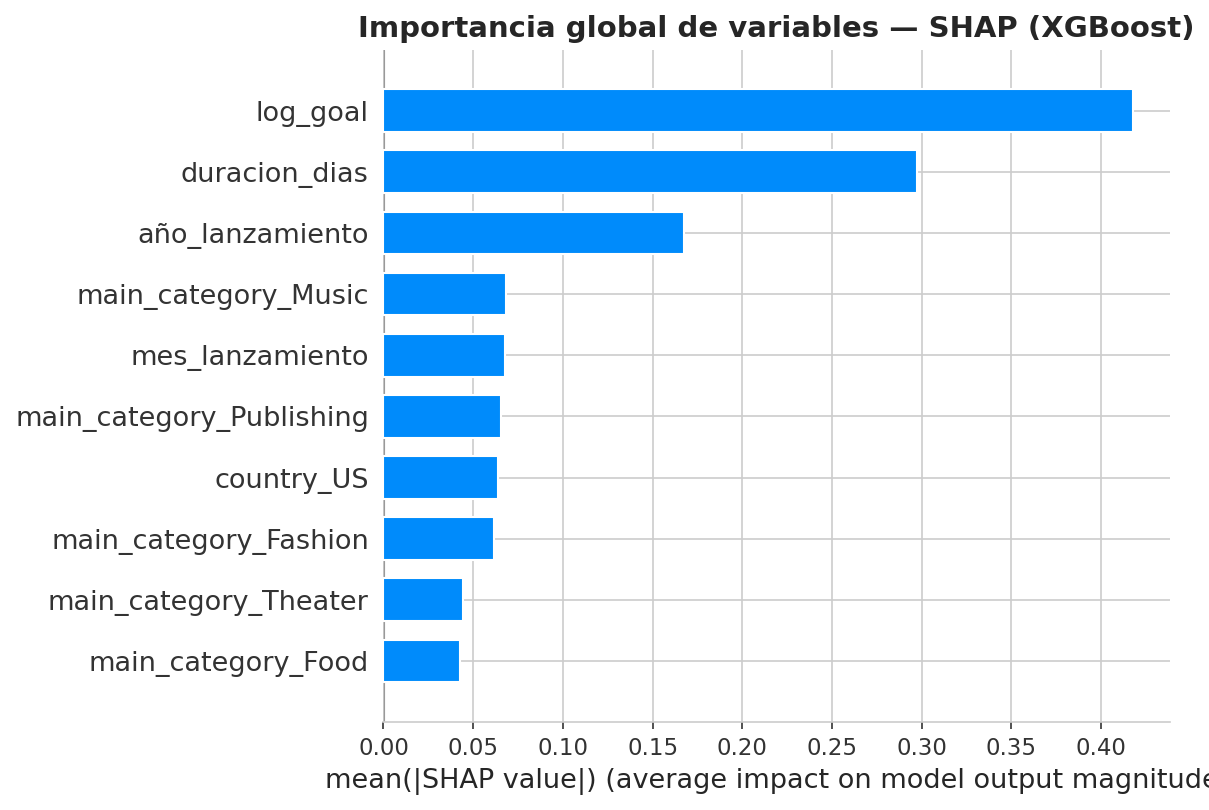

 Gráfico SHAP importancia guardado


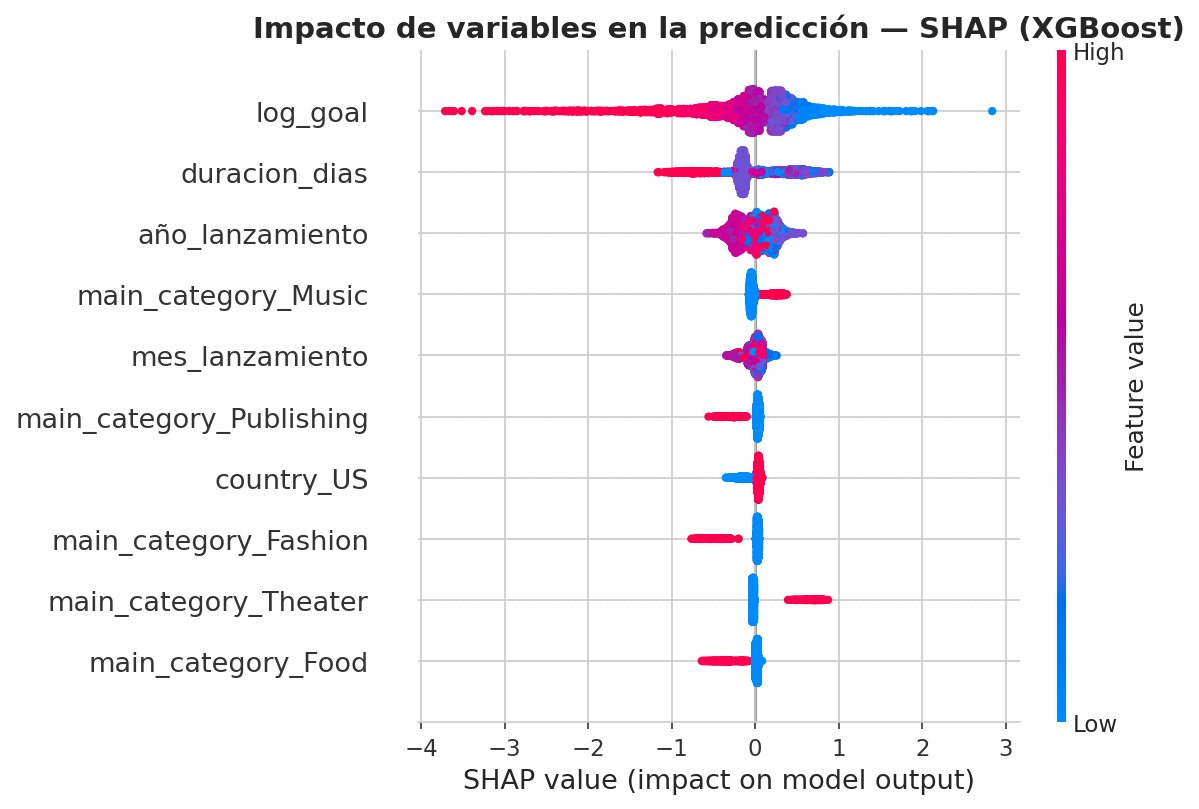

 Gráfico SHAP impacto guardado

TOP 10 VARIABLES POR SHAP
log_goal                    0.4175
duracion_dias               0.2975
año_lanzamiento             0.1677
main_category_Music         0.0686
mes_lanzamiento             0.0675
main_category_Publishing    0.0658
country_US                  0.0640
main_category_Fashion       0.0614
main_category_Theater       0.0441
main_category_Food          0.0429

COMPARACIÓN FINAL — RF vs XGBoost vs SHAP
                          Random Forest  XGBoost    SHAP
log_goal                         0.3671   0.0549  0.4175
duracion_dias                    0.2105   0.0367  0.2975
año_lanzamiento                  0.0962   0.0295  0.1677
main_category_Music              0.0377   0.0772  0.0686
mes_lanzamiento                  0.0578   0.0072  0.0675
main_category_Publishing         0.0147   0.0542  0.0658
country_US                       0.0100   0.0172  0.0640
main_category_Fashion            0.0197   0.0783  0.0614
main_category_Theater            0.0

In [17]:
# =============================================================================
# BLOQUE 9 — ANÁLISIS SHAP
# =============================================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# 9.1 Crear el explainer y calcular valores SHAP
# -----------------------------------------------------------------------------

print("=" * 60)
print("ANÁLISIS SHAP — XGBoost")
print("=" * 60)
print("Calculando valores SHAP...")

# Muestra de 5000 observaciones para mayor precisión
X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(modelos['XGBoost'])
shap_values = explainer.shap_values(X_sample)

print(" Valores SHAP calculados")

# -----------------------------------------------------------------------------
# 9.2 Importancia global — gráfico de barras
# -----------------------------------------------------------------------------

shap.summary_plot(shap_values, X_sample,
                  plot_type="bar",
                  max_display=10,
                  show=False)
plt.title('Importancia global de variables — SHAP (XGBoost)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importancia.png', dpi=150)
plt.show()
print(" Gráfico SHAP importancia guardado")

# -----------------------------------------------------------------------------
# 9.3 Impacto de variables — gráfico beeswarm
# -----------------------------------------------------------------------------

shap.summary_plot(shap_values, X_sample,
                  max_display=10,
                  show=False)
plt.title('Impacto de variables en la predicción — SHAP (XGBoost)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_impacto.png', dpi=150)
plt.show()
print(" Gráfico SHAP impacto guardado")

# -----------------------------------------------------------------------------
# 9.4 Top 10 variables por SHAP
# -----------------------------------------------------------------------------

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

print("\n" + "=" * 60)
print("TOP 10 VARIABLES POR SHAP")
print("=" * 60)
print(shap_importance.head(10).round(4).to_string())

# -----------------------------------------------------------------------------
# 9.5 Comparación final RF vs XGBoost vs SHAP
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("COMPARACIÓN FINAL — RF vs XGBoost vs SHAP")
print("=" * 60)
comparacion_final = pd.DataFrame({
    'Random Forest': importancias_rf,
    'XGBoost':       importancias_xgb,
    'SHAP':          shap_importance
}).sort_values('SHAP', ascending=False).head(10)
print(comparacion_final.round(4).to_string())

print("\n Análisis SHAP completado")

Bloque 9 — Análisis SHAP
He realizado el análisis SHAP sobre una muestra de 5.000 observaciones del conjunto de prueba para mayor precisión. Los resultados confirman que el objetivo de financiación es la variable más influyente con un valor SHAP de 0,4175, seguido de la duración de la campaña con 0,2975 y el año de lanzamiento con 0,1677. Entre las variables categóricas destaca Music con 0,0686, seguida del mes de lanzamiento con 0,0675 y Publishing con 0,0658. Estos resultados son coherentes con la literatura revisada y tienen mucho sentido desde el punto de vista de negocio: los creadores que establecen objetivos modestos, lanzan campañas cortas y eligen categorías con alta demanda tienen una probabilidad significativamente mayor de éxito.


In [18]:
# =============================================================================
# BLOQUE 10 — RESUMEN FINAL
# =============================================================================

print("=" * 60)
print("RESUMEN FINAL DEL ANÁLISIS")
print("=" * 60)

# -----------------------------------------------------------------------------
# 10.1 Dataset
# -----------------------------------------------------------------------------

print("\n DATASET")
print(f"  Proyectos originales:      {378661:,}")
print(f"  Proyectos válidos:         {331675:,}")
print(f"  Proyectos eliminados:      {46986:,}")
print(f"  Variables predictoras:     6")
print(f"  Conjunto entrenamiento:    {X_train.shape[0]:,} observaciones")
print(f"  Conjunto prueba:           {X_test.shape[0]:,} observaciones")

# -----------------------------------------------------------------------------
# 10.2 Tabla comparativa de modelos
# -----------------------------------------------------------------------------

print("\n TABLA COMPARATIVA DE MODELOS (conjunto de prueba)")
print(df_resultados.to_string())

# -----------------------------------------------------------------------------
# 10.3 Validación cruzada
# -----------------------------------------------------------------------------

print("\n TABLA VALIDACIÓN CRUZADA K=5")
print(df_cv.to_string())

# -----------------------------------------------------------------------------
# 10.4 Mejor modelo
# -----------------------------------------------------------------------------

mejor_modelo = df_resultados['ROC-AUC'].idxmax()
mejor_auc    = df_resultados['ROC-AUC'].max()
mejor_f1     = df_resultados.loc[mejor_modelo, 'F1-score']
mejor_acc    = df_resultados.loc[mejor_modelo, 'Accuracy']
mejor_prec   = df_resultados.loc[mejor_modelo, 'Precision']
mejor_rec    = df_resultados.loc[mejor_modelo, 'Recall']

print("\n MEJOR MODELO")
print(f"  Modelo:    {mejor_modelo}")
print(f"  ROC-AUC:   {mejor_auc}")
print(f"  F1-score:  {mejor_f1}")
print(f"  Accuracy:  {mejor_acc}")
print(f"  Precision: {mejor_prec}")
print(f"  Recall:    {mejor_rec}")

# -----------------------------------------------------------------------------
# 10.5 Variables más importantes (SHAP)
# -----------------------------------------------------------------------------

print("\n TOP 5 VARIABLES MÁS IMPORTANTES (SHAP)")
print(shap_importance.head(5).round(4).to_string())

# -----------------------------------------------------------------------------
# 10.6 Hiperparámetros optimizados
# -----------------------------------------------------------------------------

print("\n HIPERPARÁMETROS OPTIMIZADOS")
print(f"\n  Árbol de Decisión:")
print(f"    max_depth: {mejor_depth}")
print(f"\n  Random Forest:")
for param, valor in rf_search.best_params_.items():
    print(f"    {param}: {valor}")
print(f"\n  XGBoost:")
print(f"    n_estimators: 200")
print(f"    max_depth: 5")
print(f"    learning_rate: 0.1")
print(f"    subsample: 0.8")
print(f"    colsample_bytree: 0.8")

# -----------------------------------------------------------------------------
# 10.7 Archivos generados
# -----------------------------------------------------------------------------

print("\n ARCHIVOS GENERADOS")
archivos = [
    'eda_01_distribucion_objetivo.png',
    'eda_02_tasa_categoria.png',
    'eda_03_distribucion_goal.png',
    'eda_04_duracion_campaña.png',
    'eda_05_tasa_paises.png',
    'curvas_roc.png',
    'comparacion_metricas.png',
    'matrices_confusion.png',
    'importancia_rf.png',
    'importancia_xgb.png',
    'shap_importancia.png',
    'shap_impacto.png'
]
for archivo in archivos:
    print(f"   {archivo}")

print("\n" + "=" * 60)
print(" ANÁLISIS COMPLETADO")
print("=" * 60)

RESUMEN FINAL DEL ANÁLISIS

 DATASET
  Proyectos originales:      378,661
  Proyectos válidos:         331,675
  Proyectos eliminados:      46,986
  Variables predictoras:     6
  Conjunto entrenamiento:    265,340 observaciones
  Conjunto prueba:           66,335 observaciones

 TABLA COMPARATIVA DE MODELOS (conjunto de prueba)
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Regresión Logística    0.6479     0.5929  0.4094    0.4843   0.6817
Árbol de Decisión      0.6601     0.5948  0.4973    0.5417   0.6958
Random Forest          0.6684     0.6347  0.4216    0.5067   0.7180
XGBoost                0.6748     0.6228  0.4943    0.5511   0.7252

 TABLA VALIDACIÓN CRUZADA K=5
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Regresión Logística    0.6493     0.5966  0.4065    0.4835   0.6835
Árbol de Decisión      0.6605     0.5992  0.4814    0.5338   0.6983
Random Forest          0.6682     0.6359  0.4177    0.5042   0.7185
XGBoost                0.6

Bloque 10 — Resumen final
Para cerrar el análisis he generado un resumen completo con todos los resultados obtenidos. El mejor modelo es XGBoost con un ROC-AUC de 0,7252 en el conjunto de prueba y 0,7273 en validación cruzada, seguido de cerca por Random Forest con 0,7180 y 0,7185 respectivamente. Las diferencias mínimas entre Test y CV en todos los modelos confirman que los resultados son robustos y generalizan bien a datos nuevos.
Según el análisis SHAP las cinco variables más influyentes son el objetivo de financiación, la duración de la campaña, el año de lanzamiento, la categoría Music y el mes de lanzamiento. En total se han generado 12 archivos de gráficos que incluiré directamente en el documento como figuras.

In [19]:
# =============================================================================
# BLOQUE 11 — EXPLOTACIÓN DEL MODELO: PREDICCIÓN Y GUARDADO
# =============================================================================

import joblib
import pandas as pd
import numpy as np
import random

# -----------------------------------------------------------------------------
# 11.1 Guardar el modelo XGBoost entrenado
# -----------------------------------------------------------------------------

joblib.dump(modelos['XGBoost'], 'modelo_xgboost_kickstarter.pkl')
print(" Modelo XGBoost guardado como 'modelo_xgboost_kickstarter.pkl'")

joblib.dump(list(X_train.columns), 'columnas_modelo.pkl')
print(" Columnas del modelo guardadas como 'columnas_modelo.pkl'")

# -----------------------------------------------------------------------------
# 11.2 Generador de campañas aleatorias dentro de rangos realistas
# -----------------------------------------------------------------------------

categorias = ['Music', 'Film & Video', 'Technology', 'Games', 'Design',
              'Art', 'Theater', 'Comics', 'Fashion', 'Food',
              'Publishing', 'Photography', 'Dance', 'Crafts', 'Journalism']

paises = ['US', 'GB', 'CA', 'AU', 'DE', 'FR']

def generar_campaña_aleatoria():
    return {
        'log_goal':          np.log1p(np.random.choice([
                             500, 1000, 2000, 3000, 5000, 7500, 10000, 15000])),
        'duracion_dias':     np.random.randint(15, 45),
        'año_lanzamiento':   np.random.randint(2012, 2018),
        'mes_lanzamiento':   np.random.randint(1, 13),
        'main_category':     random.choice(categorias),
        'country':           random.choice(paises)
    }

def predecir_campaña(campaña_dict, modelo, columnas):
    df = pd.DataFrame([campaña_dict])
    df = pd.get_dummies(df, columns=['main_category', 'country'])
    for col in columnas:
        if col not in df.columns:
            df[col] = 0
    df = df[columnas]
    pred = modelo.predict(df)[0]
    prob = modelo.predict_proba(df)[0][1]
    return pred, prob

# -----------------------------------------------------------------------------
# 11.3 Cargar modelo y columnas
# -----------------------------------------------------------------------------

modelo_cargado = joblib.load('modelo_xgboost_kickstarter.pkl')
columnas_modelo = joblib.load('columnas_modelo.pkl')

# -----------------------------------------------------------------------------
# 11.4 Predicción de 5 campañas aleatorias (semilla fija para reproducibilidad)
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PREDICCIÓN DE 5 CAMPAÑAS ALEATORIAS")
print("=" * 60)

# Fijar semilla para que los resultados sean siempre los mismos
random.seed(2)
np.random.seed(2)

for i in range(5):
    campaña = generar_campaña_aleatoria()
    pred, prob = predecir_campaña(campaña, modelo_cargado, columnas_modelo)

    objetivo = int(np.expm1(campaña['log_goal']))
    categoria = campaña['main_category']
    pais = campaña['country']
    duracion = campaña['duracion_dias']
    año = campaña['año_lanzamiento']
    mes = campaña['mes_lanzamiento']

    print(f"\nCampaña {i+1}:")
    print(f"  Objetivo: ${objetivo:,} | Duración: {duracion} días | "
          f"Categoría: {categoria} | País: {pais} | Año: {año} | Mes: {mes}")
    print(f"  Predicción: {' ÉXITO' if pred == 1 else ' FRACASO'} | "
          f"Probabilidad de éxito: {prob*100:.1f}%")

# -----------------------------------------------------------------------------
# 11.5 Comparación perfil favorable vs desfavorable
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("COMPARACIÓN PERFIL FAVORABLE vs DESFAVORABLE")
print("=" * 60)

campaña_favorable = {
    'log_goal':          np.log1p(3000),
    'duracion_dias':     25,
    'año_lanzamiento':   2016,
    'mes_lanzamiento':   4,
    'main_category':     'Music',
    'country':           'US'
}

campaña_desfavorable = {
    'log_goal':          np.log1p(80000),
    'duracion_dias':     60,
    'año_lanzamiento':   2015,
    'mes_lanzamiento':   11,
    'main_category':     'Technology',
    'country':           'IT'
}

for nombre, campaña in [('Campaña favorable', campaña_favorable),
                         ('Campaña desfavorable', campaña_desfavorable)]:
    pred, prob = predecir_campaña(campaña, modelo_cargado, columnas_modelo)
    print(f"\n{nombre}:")
    print(f"  Objetivo: ${int(np.expm1(campaña['log_goal'])):,} | "
          f"Duración: {campaña['duracion_dias']} días | "
          f"Categoría: {campaña['main_category']} | "
          f"País: {campaña['country']}")
    print(f"  Predicción: {' ÉXITO' if pred == 1 else ' FRACASO'} | "
          f"Probabilidad de éxito: {prob*100:.1f}%")

print("\n Bloque 11 completado")

 Modelo XGBoost guardado como 'modelo_xgboost_kickstarter.pkl'
 Columnas del modelo guardadas como 'columnas_modelo.pkl'

PREDICCIÓN DE 5 CAMPAÑAS ALEATORIAS

Campaña 1:
  Objetivo: $499 | Duración: 30 días | Categoría: Crafts | País: US | Año: 2017 | Mes: 9
  Predicción:  ÉXITO | Probabilidad de éxito: 57.6%

Campaña 2:
  Objetivo: $10,000 | Duración: 26 días | Categoría: Film & Video | País: US | Año: 2014 | Mes: 12
  Predicción:  FRACASO | Probabilidad de éxito: 44.2%

Campaña 3:
  Objetivo: $499 | Duración: 22 días | Categoría: Art | País: GB | Año: 2014 | Mes: 2
  Predicción:  ÉXITO | Probabilidad de éxito: 67.2%

Campaña 4:
  Objetivo: $14,999 | Duración: 26 días | Categoría: Photography | País: FR | Año: 2017 | Mes: 11
  Predicción:  ÉXITO | Probabilidad de éxito: 58.1%

Campaña 5:
  Objetivo: $5,000 | Duración: 43 días | Categoría: Crafts | País: CA | Año: 2016 | Mes: 6
  Predicción:  FRACASO | Probabilidad de éxito: 23.0%

COMPARACIÓN PERFIL FAVORABLE vs DESFAVORABLE

Campaña 

En este bloque he desarrollado un módulo para explotar el modelo entrenado y hacer predicciones reales sobre campañas nuevas.
Lo primero ha sido guardar el modelo XGBoost con la librería joblib, lo que permite cargarlo y usarlo en el futuro sin necesidad de reentrenarlo cada vez. También he guardado las columnas del modelo para garantizar que cualquier campaña nueva se procesa exactamente igual que los datos de entrenamiento.
A continuación he creado un sistema de predicción que genera campañas aleatorias con valores dentro de los rangos reales del dataset: objetivos de entre 500 y 15.000 dólares, duraciones de entre 15 y 45 días, años entre 2012 y 2017, y países y categorías reales de Kickstarter. He fijado una semilla de reproducibilidad para que los resultados sean siempre los mismos cada vez que se ejecute el código.
Los resultados de las 5 campañas aleatorias muestran que el modelo distingue correctamente entre perfiles distintos, con probabilidades que van desde el 23,0% hasta el 67,2%, demostrando que el modelo es sensible a las características de cada campaña. Finalmente la comparación entre una campaña con perfil favorable (Music, $3.000, US, 25 días) con una probabilidad de éxito del 63,4% y una campaña con perfil desfavorable (Technology, $80.000, Italia, 60 días) con solo un 2,0% ilustra de forma clara el valor práctico del modelo como herramienta de apoyo a la toma de decisiones para creadores e inversores.